# Higgs Boson Events classification Using Accelerated Computing with RAPIDS

---

This notebook implements a full GPU-accelerated ML pipeline to classify particle collision events from CERN's Large Hadron Collider (LHC). The goal is to distinguish signal events (Higgs boson produced) from background events (no Higgs boson produced). All GPU operations use the NVIDIA RAPIDS framework (cuDF, cuML). A CPU vs GPU benchmark compares training performance directly.

**Hardware:** NVIDIA RTX 3090 (24GB VRAM)
**Framework:** RAPIDS 23.08 — cuDF, cuML, XGBoost 1.7.4


## Data Pre-processing, Exploartory Data Analysis and PCA.

### Importing Libraries

Two sets of libraries are imported. The GPU libraries (RAPIDS) include cuDF for GPU DataFrames and cuML for GPU machine learning, these run directly on the RTX 3090 GPU. The CPU libraries namely pandas, numpy, and sklearn  are used only for the CPU benchmark comparison and for matplotlib/seaborn plotting which requires pandas format. Matplotlib and seaborn handle all visualisations. The time library measures training speed for the CPU vs GPU benchmark.

Before any RAPIDS library is imported, the environment variable NUMBA_CUDA_USE_NVIDIA_BINDING is set to 1. This switches numba from its default ctypes-based CUDA driver interface to NVIDIA's official Python CUDA bindings. Under WSL2, the default ctypes interface fails to initialise the CUDA context correctly, producing the following error when any GPU operation is attempted:

CudaAPIError: [201] Call to cuCtxGetDevice results in CUDA_ERROR_INVALID_CONTEXT

Setting NUMBA_CUDA_USE_NVIDIA_BINDING=1 before any RAPIDS import resolves this by ensuring numba uses the correct driver interface from the start.

In [1]:
import os
os.environ['NUMBA_CUDA_USE_NVIDIA_BINDING'] = '1'

import warnings
warnings.filterwarnings('ignore')

# GPU libraries — RAPIDS
import cudf
import cuml
import cupy as cp
from cuml.decomposition import PCA
from cuml.preprocessing import StandardScaler
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.model_selection import train_test_split

# CPU libraries — benchmark and plotting only
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier as skRF

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import time
import psutil

print('All libraries imported successfully.')
print(f'cuDF version: {cudf.__version__}')
print(f'cuML version: {cuml.__version__}')

All libraries imported successfully.
cuDF version: 23.08.00
cuML version: 23.08.00


### Load Dataset with cuDF
The dataset is loaded using cudf.read_csv() which reads the file directly into GPU memory. This is faster than pandas for large files because cuDF distributes the read operation across GPU cores. The %%time magic records the loading time.

In [2]:
%%time

df = cudf.read_csv('Partical.csv',  header=None)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Column labels: {list(df.columns)}')

Shape: 11,000,000 rows x 29 columns
Column labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28']
CPU times: user 3.42 s, sys: 5.15 s, total: 8.56 s
Wall time: 10.1 s


In [3]:
# Show the dataframe with rows and columns
df

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10999995,1.0,1.159912,1.013847,0.108615,1.495524,-0.537545,2.342396,-0.839740,1.320683,0.000000,...,-0.097068,1.190680,3.101961,0.822136,0.766772,1.002191,1.061233,0.837004,0.860472,0.772484
10999996,1.0,0.618388,-1.012982,1.110139,0.941023,-0.379199,1.004656,0.348535,-1.678593,2.173076,...,-0.216995,1.049177,3.101961,0.826829,0.989809,1.029104,1.199679,0.891481,0.938490,0.865269
10999997,1.0,0.700559,0.774251,1.520182,0.847112,0.211230,1.095531,0.052457,0.024553,2.173076,...,1.585235,1.713962,0.000000,0.337374,0.845208,0.987610,0.883422,1.888438,1.153766,0.931279
10999998,0.0,1.178030,0.117796,-1.276980,1.864457,-0.584370,0.998519,-1.264549,1.276333,0.000000,...,1.399515,-1.313189,0.000000,0.838842,0.882890,1.201380,0.939216,0.339705,0.759070,0.719119


The output confirms the dataset loaded correctly. It contains 11,000,000 rows and 29 columns. The columns are currently numbered 0 to 28 because the file has no header row.

Column 0 contains only the values 1.0 and 0.0. This is the class label where 1.0 represents a signal event (Higgs boson produced) and 0.0 represents a background event (no Higgs boson produced).
Columns 1 to 28 contain decimal numbers representing the 28 kinematic features measured by the detector. The values range roughly between 3 and 3 which is consistent with normalised physics measurements. The dots in the middle of the display indicate that JupyterLab is truncating the columns and rows for display purposes only. All 29 columns and 11 million rows are present in memory.

### Assign Column Names and Inspect Structure

The dataset has no header row so column names are assigned  based on the feature descriptions in the UCI HIGGS dataset repository. Column 0 is the class label. Columns 1 to 21 are low level kinematic features measured directly by the detector including transverse momentum (pT), pseudorapidity (eta), azimuthal angle (phi), missing energy, and b-tag values for the lepton and four jets. Columns 22 to 28 are high level features derived by physicists from the low level measurements including invariant masses mjj, mjjj, mlv, mjlv, mbb, mwbb and m_wwbb.

In [4]:
column_names = [
    'class_label',
    'lepton_pT', 'lepton_eta', 'lepton_phi',
    'missing_energy_magnitude', 'missing_energy_phi',
    'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_b_tag',
    'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_b_tag',
    'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_b_tag',
    'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_b_tag',
    'mjj', 'mjjj', 'mlv', 'mjlv', 'mbb', 'mwbb', 'm_wwbb'
]

df.columns = column_names

# Show the top 5 rows
df.head()

,class_label,lepton_pT,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b_tag,...,jet_4_eta,jet_4_phi,jet_4_b_tag,mjj,mjjj,mlv,mjlv,mbb,mwbb,m_wwbb
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


In [5]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 11000000 entries, 0 to 10999999
Data columns (total 29 columns):
 #   Column                    Dtype
---  ------                    -----
 0   class_label               float64
 1   lepton_pT                 float64
 2   lepton_eta                float64
 3   lepton_phi                float64
 4   missing_energy_magnitude  float64
 5   missing_energy_phi        float64
 6   jet_1_pt                  float64
 7   jet_1_eta                 float64
 8   jet_1_phi                 float64
 9   jet_1_b_tag               float64
 10  jet_2_pt                  float64
 11  jet_2_eta                 float64
 12  jet_2_phi                 float64
 13  jet_2_b_tag               float64
 14  jet_3_pt                  float64
 15  jet_3_eta                 float64
 16  jet_3_phi                 float64
 17  jet_3_b_tag               float64
 18  jet_4_pt                  float64
 19  jet_4_eta                 float64
 20  jet_4_phi               

The dataset contains 11,000,000 entries across 29 columns. All columns are float64. The total memory usage in GPU memory is 2.4 GB.

### Descriptive statistics summary

The summary shows the mean, standard deviation, minimum, maximum and quartile values for each feature. This gives an initial picture of the range and spread of each column before any analysis is done.

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
class_label,11000000.0,0.529920,0.499104,0.000000,0.000000,1.000000,1.000000,1.000000
lepton_pT,11000000.0,0.991466,0.565378,0.274697,0.590753,0.853371,1.236226,12.098914
lepton_eta,11000000.0,-0.000008,1.008827,-2.434976,-0.738322,-0.000054,0.738214,2.434868
lepton_phi,11000000.0,-0.000013,1.006346,-1.742508,-0.871931,-0.000241,0.870994,1.743236
missing_energy_magnitude,11000000.0,0.998536,0.600018,0.000237,0.576816,0.891628,1.293056,15.396821
missing_energy_phi,11000000.0,0.000026,1.006326,-1.743944,-0.871208,0.000213,0.871471,1.743257
jet_1_pt,11000000.0,0.990915,0.474975,0.137502,0.678993,0.894819,1.170740,9.940391
jet_1_eta,11000000.0,-0.000020,1.009303,-2.969725,-0.687245,-0.000025,0.687194,2.969674
jet_1_phi,11000000.0,0.000008,1.005901,-1.741237,-0.868096,0.000058,0.868313,1.741454
jet_1_b_tag,11000000.0,0.999969,1.027808,0.000000,0.000000,1.086538,2.173076,2.173076


In [7]:
#Checking for missing values
df.isnull().sum()

class_label                 0
lepton_pT                   0
lepton_eta                  0
lepton_phi                  0
missing_energy_magnitude    0
missing_energy_phi          0
jet_1_pt                    0
jet_1_eta                   0
jet_1_phi                   0
jet_1_b_tag                 0
jet_2_pt                    0
jet_2_eta                   0
jet_2_phi                   0
jet_2_b_tag                 0
jet_3_pt                    0
jet_3_eta                   0
jet_3_phi                   0
jet_3_b_tag                 0
jet_4_pt                    0
jet_4_eta                   0
jet_4_phi                   0
jet_4_b_tag                 0
mjj                         0
mjjj                        0
mlv                         0
mjlv                        0
mbb                         0
mwbb                        0
m_wwbb                      0
dtype: int64

The missing value check confirms that all 29 columns contain zero missing values across all 11,000,000 rows.

### Checking for duplicates

In [8]:
duplicate_count = df.duplicated().sum()
total_rows = len(df)
duplicate_pct = (duplicate_count / total_rows) * 100


print(f'Duplicate rows: {duplicate_count:,}')
print(f'Percentage: {duplicate_pct:.2f}%')


Duplicate rows: 278,698
Percentage: 2.53%


The dataset contains 278,698 duplicate rows (2.53% of the total). As the data were generated via Monte Carlo simulations, such duplicates can arise naturally from repeated sampling of similar events rather than true measurement repetition. 

In [9]:
# Group identical rows together and count how many times each unique row appears
duplicates_pd = df[df.duplicated(keep=False)].to_pandas()
dup_value_counts = duplicates_pd.value_counts()

# Total number of unique duplicate groups
print(f'Total duplicate groups: {len(dup_value_counts):,}')
print()

# Count how many groups appear exactly twice, three times etc
print('--- How many times each duplicate row appears ---')
print(dup_value_counts.value_counts().to_string())

Total duplicate groups: 274,574

--- How many times each duplicate row appears ---
2    270450
3      4124


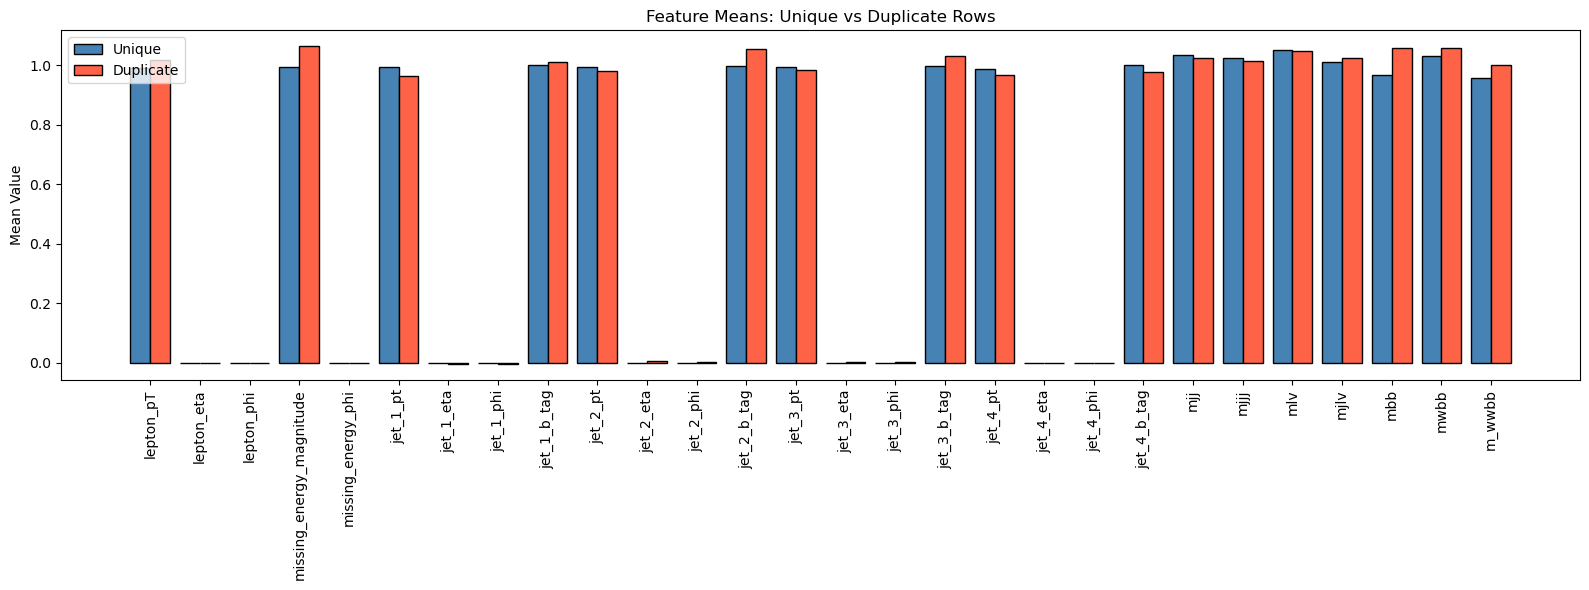

In [10]:
duplicates_pd = df[df.duplicated(keep=False)].to_pandas()
unique_pd = df[~df.duplicated(keep=False)].to_pandas()

feature_cols = [c for c in df.columns if c != 'class_label']

dup_means = duplicates_pd[feature_cols].mean()
unique_means = unique_pd[feature_cols].mean()

x = range(len(feature_cols))
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar([i - 0.2 for i in x], unique_means, width=0.4, 
       label='Unique', color='steelblue', edgecolor='black')
ax.bar([i + 0.2 for i in x], dup_means, width=0.4, 
       label='Duplicate', color='tomato', edgecolor='black')
ax.set_xticks(list(x))
ax.set_xticklabels(feature_cols, rotation=90)
ax.set_title('Feature Means: Unique vs Duplicate Rows')
ax.set_ylabel('Mean Value')
ax.legend()
plt.tight_layout()
plt.show()

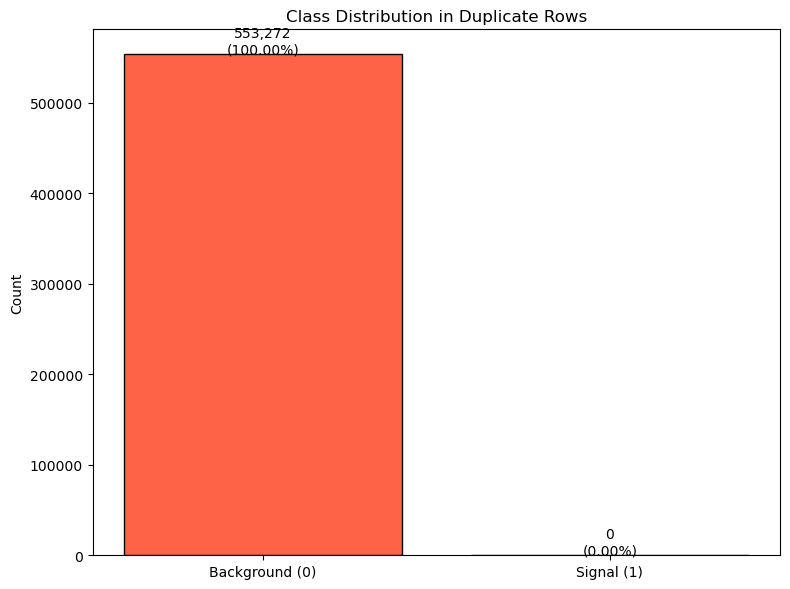

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

dup_counts = duplicates_pd['class_label'].value_counts()
total_dups = len(duplicates_pd)

ax.bar(['Background (0)', 'Signal (1)'],
       [dup_counts.get(0.0, 0), dup_counts.get(1.0, 0)],
       color=['tomato', 'steelblue'], edgecolor='black')
ax.set_title('Class Distribution in Duplicate Rows')
ax.set_ylabel('Count')
for i, val in enumerate([dup_counts.get(0.0, 0), dup_counts.get(1.0, 0)]):
    pct = (val / total_dups) * 100
    ax.text(i, val + 1000, f'{val:,}\n({pct:.2f}%)', ha='center')

plt.tight_layout()
plt.show()

The feature means chart shows that duplicate and unique rows have near identical mean values across all 28 features confirming the duplicates are not concentrated around any specific placeholder values. The class distribution chart reveals that all 553,272 duplicate row occurrences belong to the background class with zero signal duplicates. This means the duplicates are artificially inflating the background count.

### Remove Duplicate RowsThe duplicate check showed d that all 278,698 duplicate rows belong exclusively to the background class. They appear as pairs and triplets spread across the featusts. Keeping them would artificially inflate the background count and skew the class distribution during trainings.

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

0

### Class Balance Check

Checking the class balance shows the proportion of signal and background events in the cleaned dataset. This is important before training any classifier because a severely imbalanced dataset can cause the model to predict the majority class for every event. This check is done after duplicate removal to reflect the true class distribution.

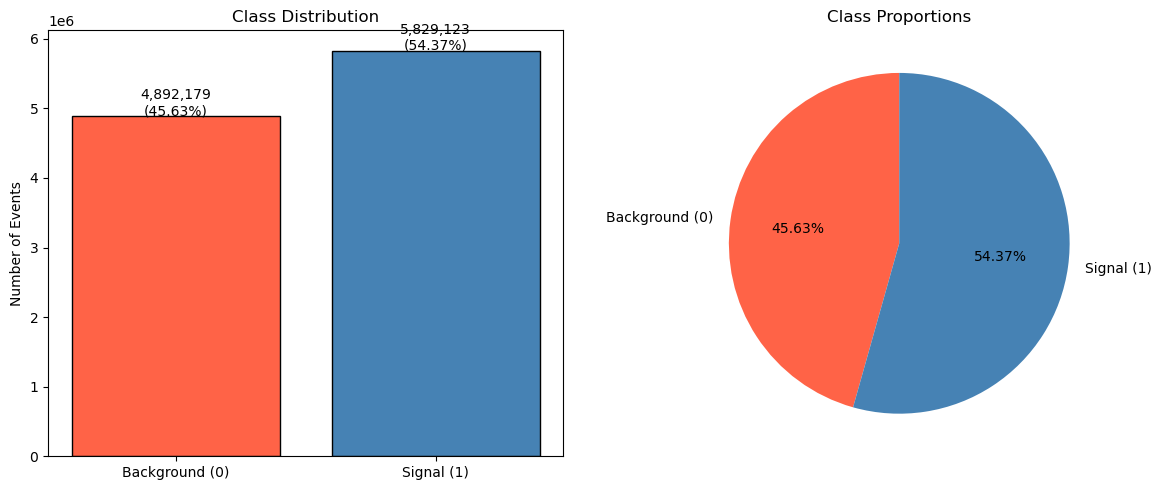

In [14]:
counts = df['class_label'].value_counts().to_pandas()
total = len(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Background (0)', 'Signal (1)'],
            [counts.get(0.0, 0), counts.get(1.0, 0)],
            color=['tomato', 'steelblue'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Events')
for i, val in enumerate([counts.get(0.0, 0), counts.get(1.0, 0)]):
    pct = (val / total) * 100
    axes[0].text(i, val + 10000, f'{val:,}\n({pct:.2f}%)', ha='center')

# Pie chart
axes[1].pie(
    [counts.get(0.0, 0), counts.get(1.0, 0)],
    labels=['Background (0)', 'Signal (1)'],
    colors=['tomato', 'steelblue'],
    autopct='%1.2f%%',
    startangle=90
)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

### Scatter Plots

Scatter plots show the relationship between pairs of features and whether signal and background events cluster in different regions. A 50,000 row sample is used to make the sure the dots are visible

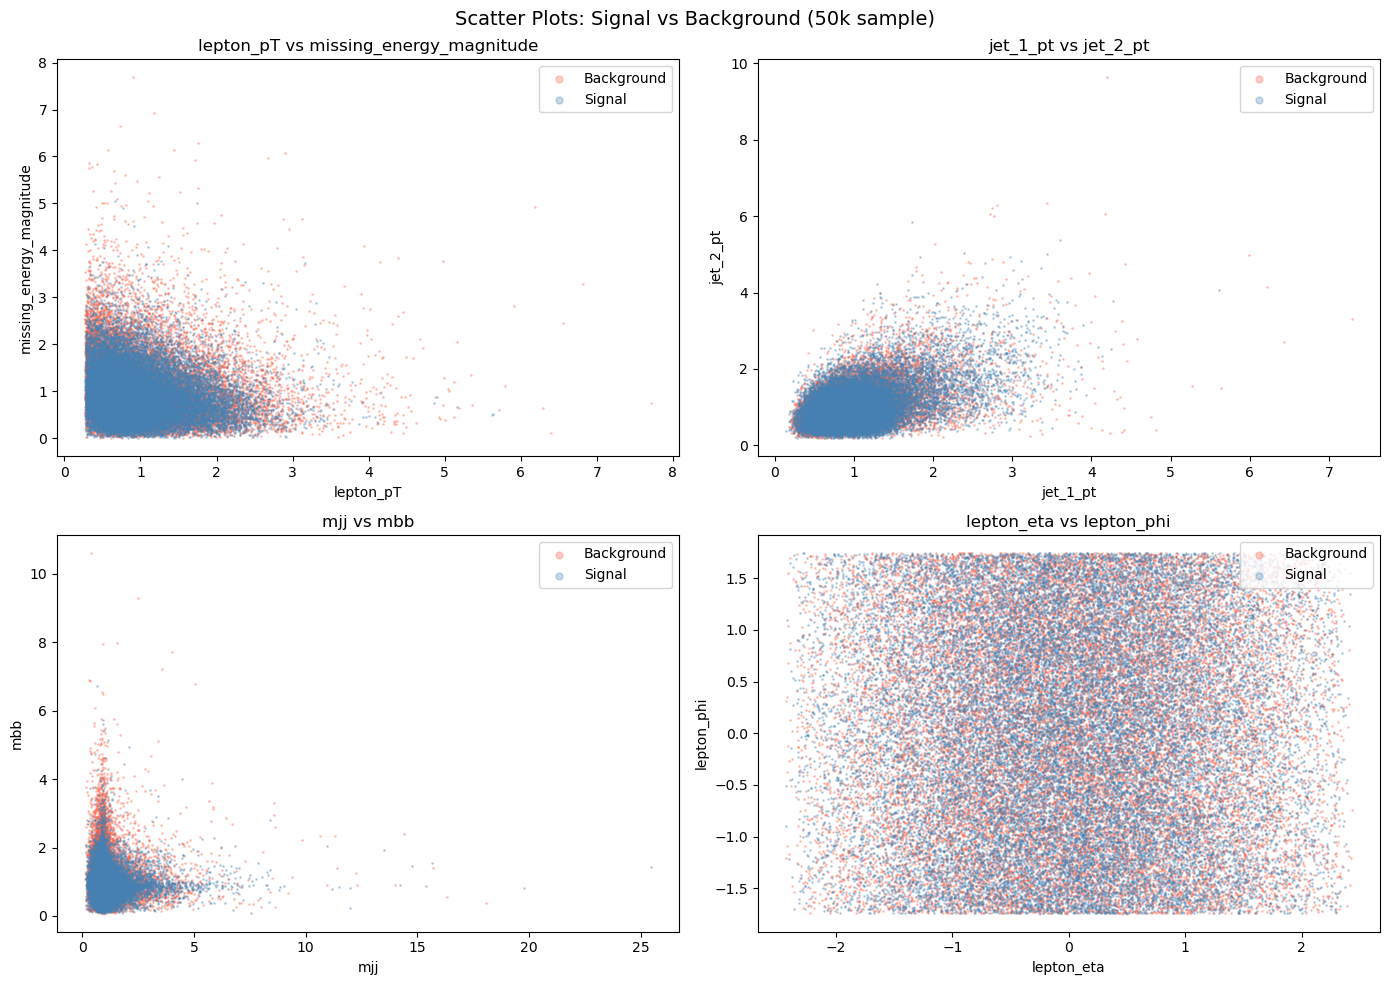

In [15]:
sample = df.sample(50000, random_state=42).to_pandas()
signal = sample[sample['class_label'] == 1.0]
background = sample[sample['class_label'] == 0.0]

scatter_pairs = [
    ('lepton_pT', 'missing_energy_magnitude'),
    ('jet_1_pt', 'jet_2_pt'),
    ('mjj', 'mbb'),
    ('lepton_eta', 'lepton_phi')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (x_feat, y_feat) in enumerate(scatter_pairs):
    axes[i].scatter(background[x_feat], background[y_feat],
                    c='tomato', alpha=0.3, s=1, label='Background')
    axes[i].scatter(signal[x_feat], signal[y_feat],
                    c='steelblue', alpha=0.3, s=1, label='Signal')
    axes[i].set_xlabel(x_feat)
    axes[i].set_ylabel(y_feat)
    axes[i].set_title(f'{x_feat} vs {y_feat}')
    axes[i].legend(loc='upper right', markerscale=5)

plt.suptitle('Scatter Plots: Signal vs Background (50k sample)', fontsize=14)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Distributions by Class

The distribution of each feature is plotted separately for signal and background events. This shows which features have visible separation between the two classes and which overlap completely. Features with clear distributional differences will carry more discriminating power for the classifier.

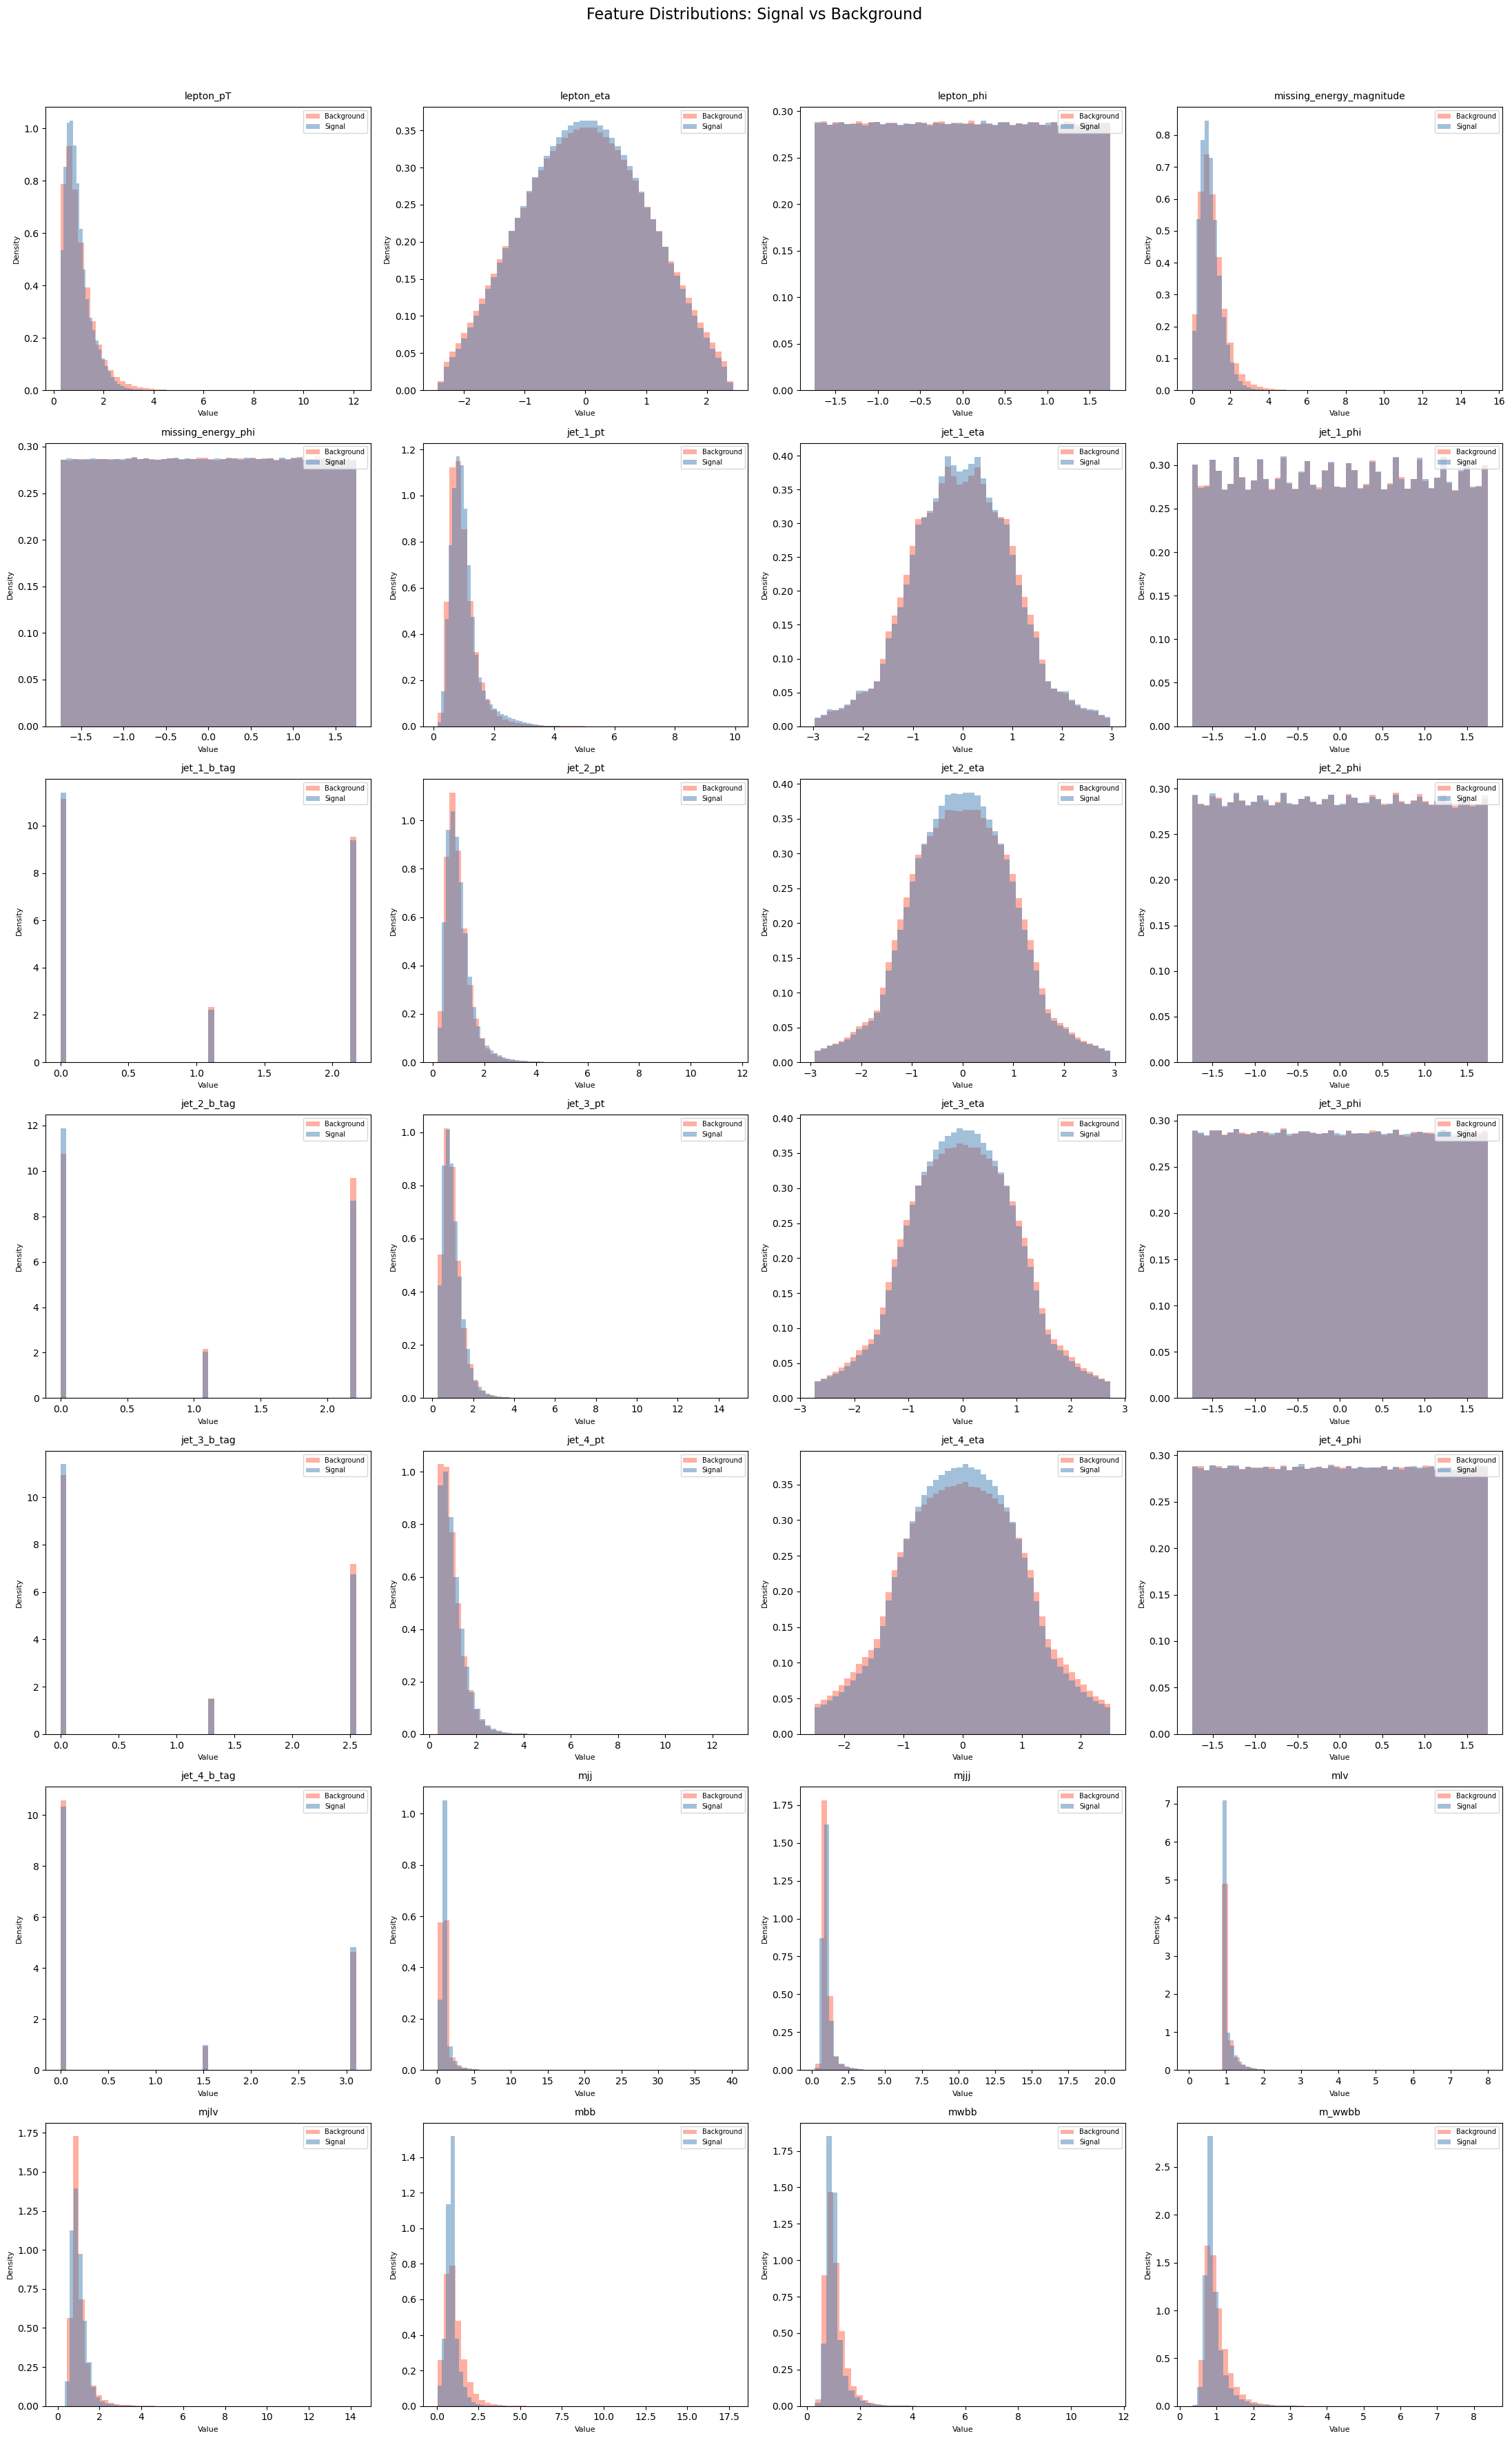

In [16]:
feature_cols = [c for c in df.columns if c != 'class_label']

signal_df = df[df['class_label'] == 1.0]
background_df = df[df['class_label'] == 0.0]

fig, axes = plt.subplots(7, 4, figsize=(22, 35))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    axes[i].hist(background_df[feat], bins=50, alpha=0.5,
                 color='tomato', label='Background', density=True)
    axes[i].hist(signal_df[feat], bins=50, alpha=0.5,
                 color='steelblue', label='Signal', density=True)
    axes[i].set_title(feat, fontsize=10, pad=8)
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Density', fontsize=8)
    axes[i].legend(fontsize=7)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Signal vs Background',
             fontsize=16, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

The feature distribution plots show how signal and background events are distributed across all 28 features.

The pT features and missing_energy_magnitude are right skewed with most values concentrated at the low end and a long tail of high values. The eta and phi features show symmetric and flat distributions centred around zero for both classes. The b_tag features show discrete distributions concentrated at a small number of values.

The variation in this data is driven by collision energy, not collision angle. When split by class, the energy and mass features confirm this. mbb, m_wwbb and missing_energy_magnitude show visible separation between signal and background. The angle features such as lepton_eta and the phi features overlap almost completely between classes. The features that separate Higgs events from background are the ones that measure how energetic the collision was, not where the particles went. This means the classifier will rely on energy and mass features to detect signal events.

### Correlation Matrix

The correlation matrix shows how strongly each pair of features moves together. Values close to 1 indicate strong positive correlation, values close to -1 indicate strong negative correlation and values close to 0 indicate little linear relationship. This helps identify which features are most linearly related to the class label and whether any features are highly correlated with each other.

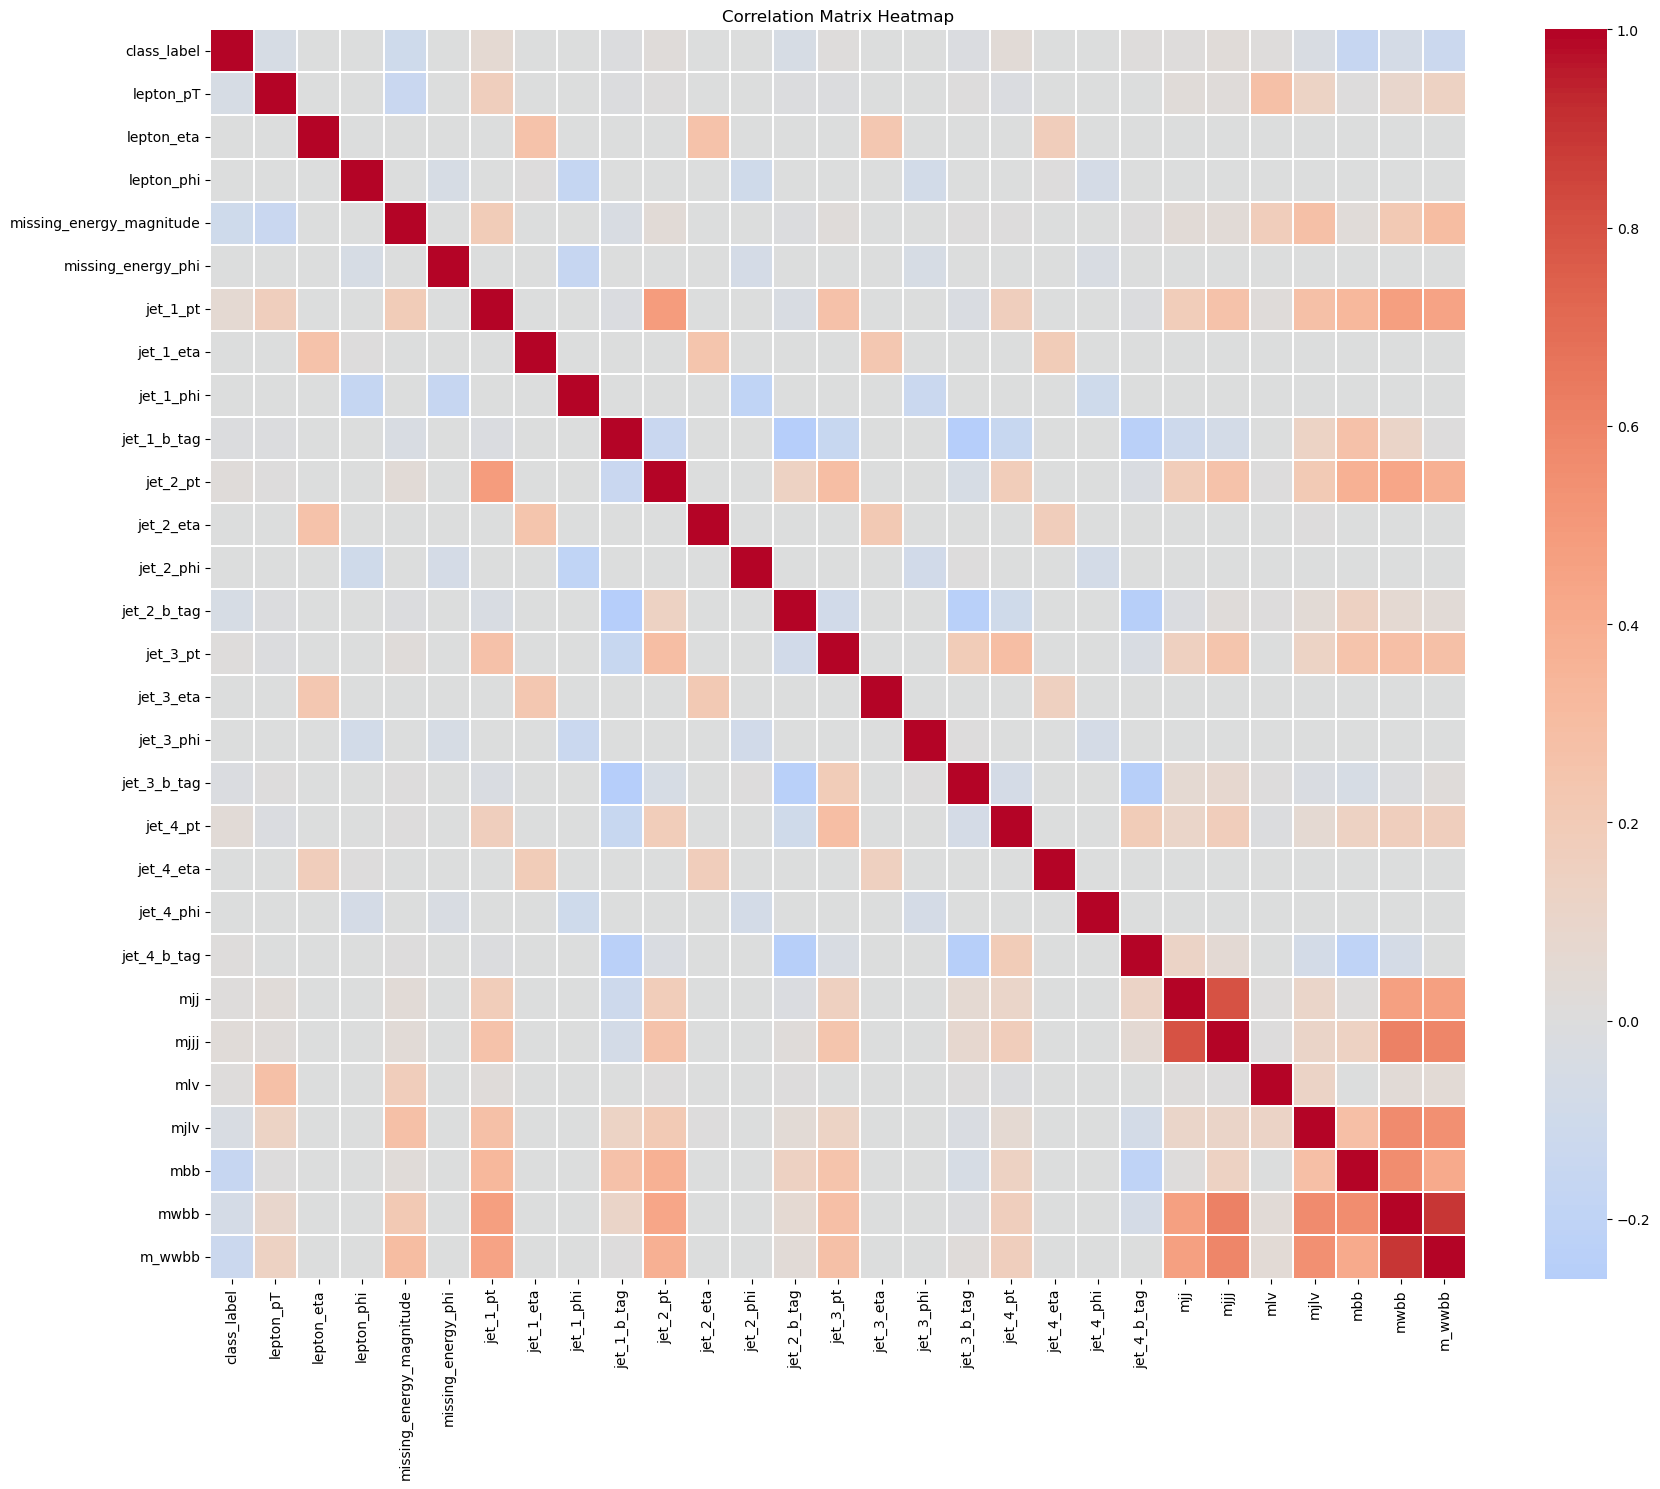

In [17]:
corr = df.corr().to_pandas()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.3,
    annot=False
)
ax.set_title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()


The correlation matrix shows that most features have weak correlation with the class label. The strongest correlations with the target are negative and come from the high level mass features, particularly m_wwbb, mwbb, mbb and missing_energy_magnitude. The strongest positive correlations come from the jet pT features. High level features correlate more strongly with the target than low level features because they were derived specifically from the physics of the Higgs decay. Inter-feature correlations are low across the matrix confirming little multicollinearity in the dataset.

###  Box Plots and Outlier Detection

Box plots show the spread of each feature. The box covers the interquartile range (Q1 to Q3), the line inside is the median and points beyond the whiskers are considered outliers by the IQR method. The IQR method flags any value below Q1 minus 1.5 times the IQR or above Q3 plus 1.5 times the IQR as an outlier. 

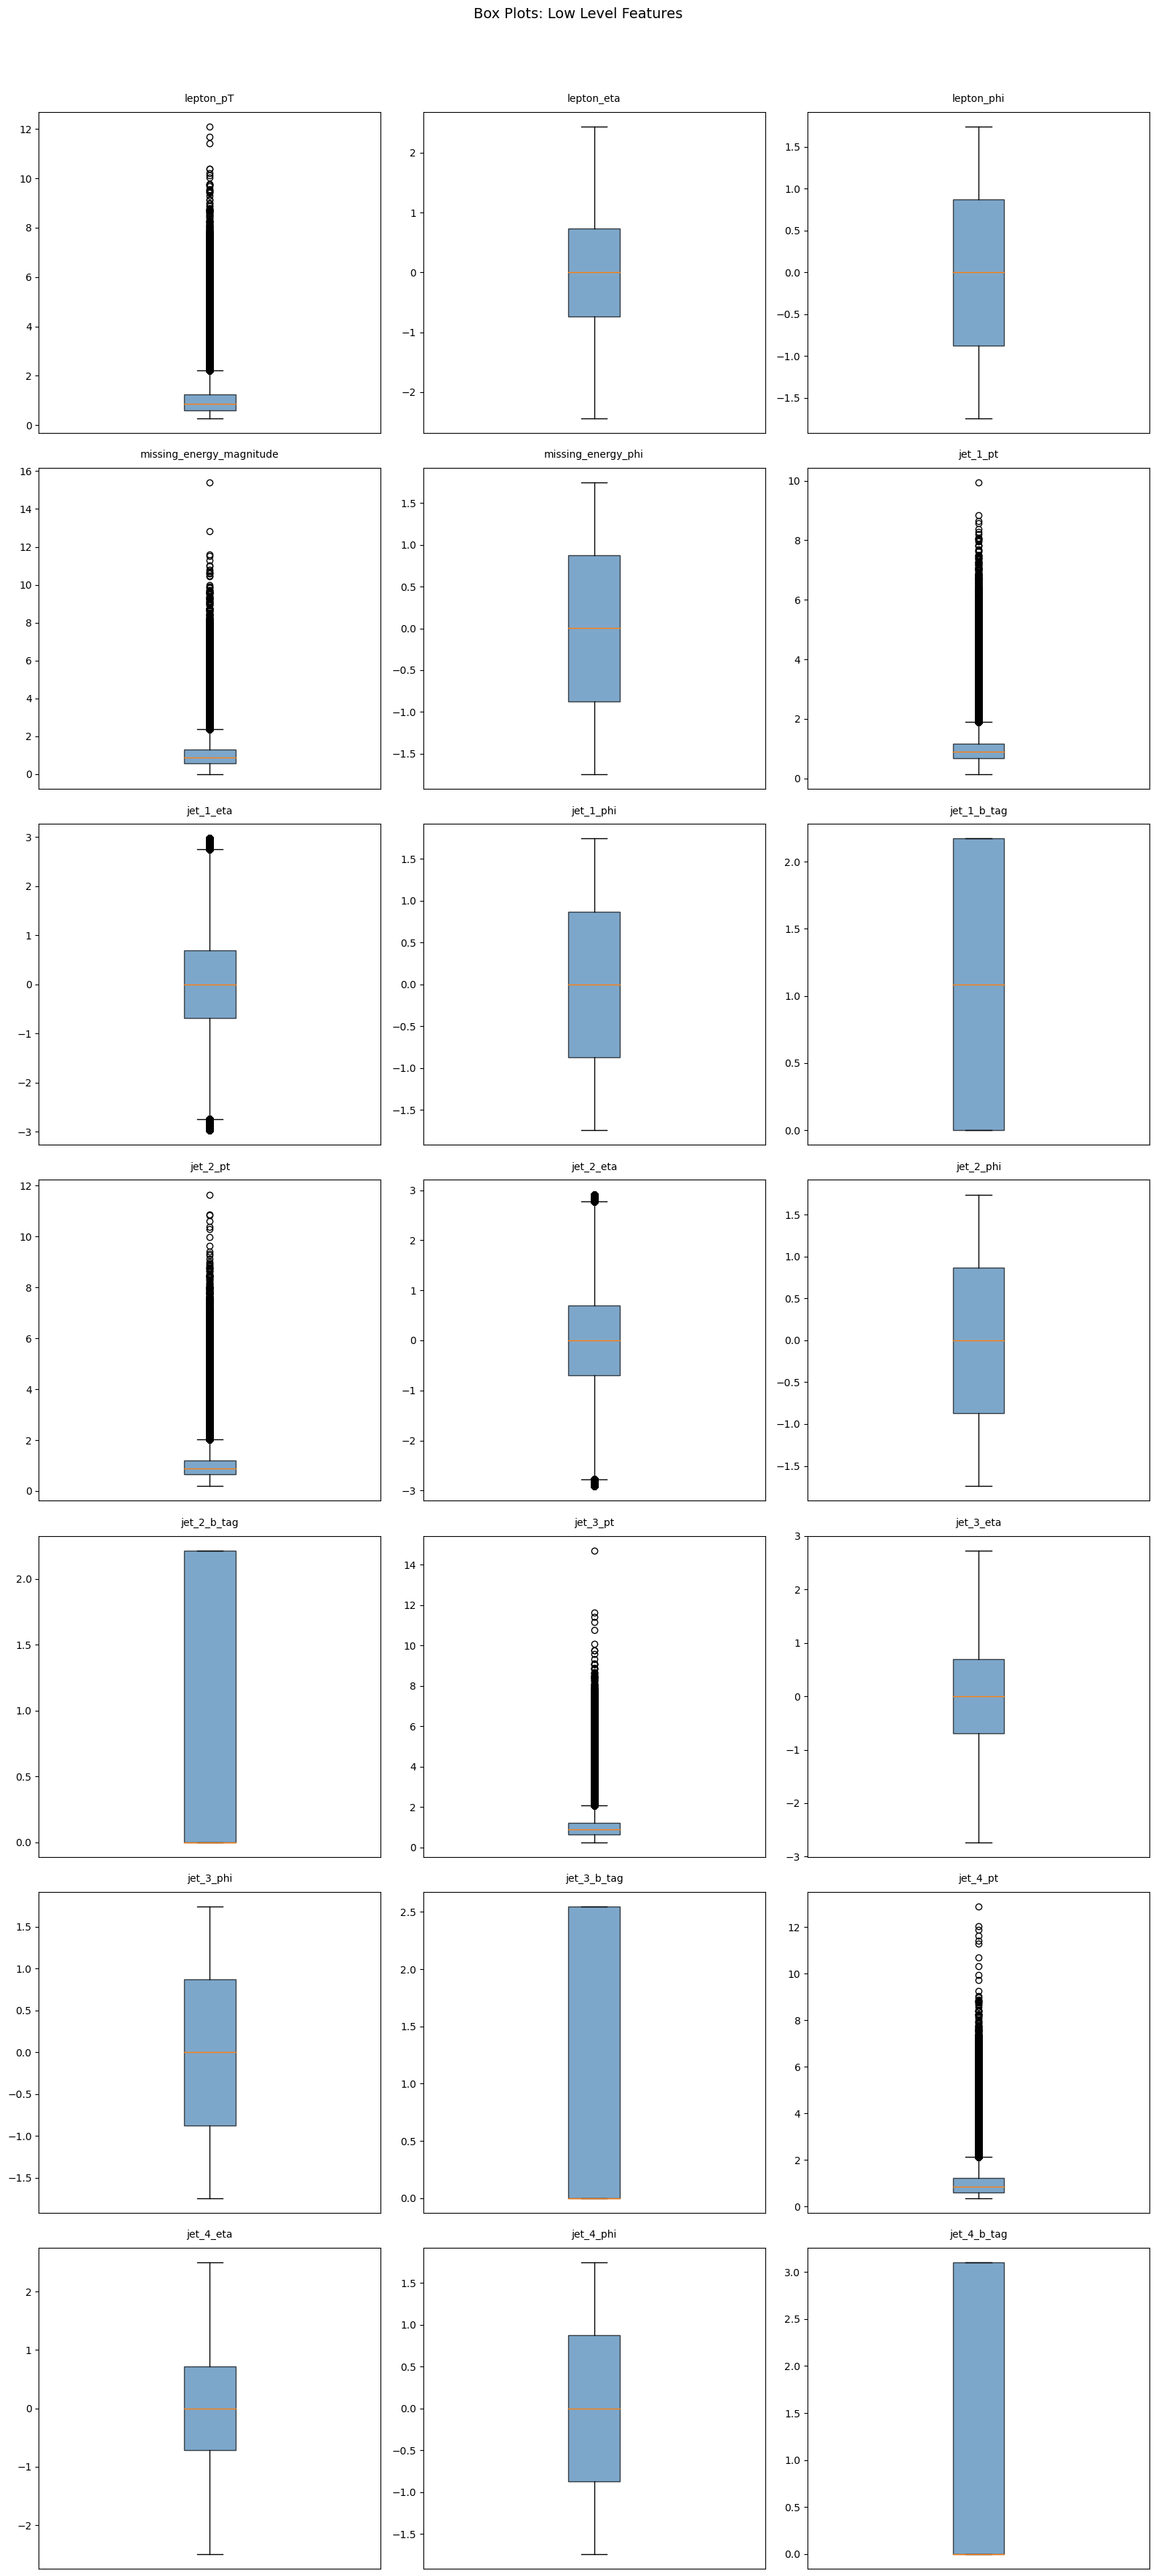

In [18]:
all_data = df.to_pandas()

low_level = [
    'lepton_pT', 'lepton_eta', 'lepton_phi',
    'missing_energy_magnitude', 'missing_energy_phi',
    'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_b_tag',
    'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_b_tag',
    'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_b_tag',
    'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_b_tag'
]

fig, axes = plt.subplots(7, 3, figsize=(16, 35))
axes = axes.flatten()
for i, feat in enumerate(low_level):
    axes[i].boxplot(all_data[feat].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(feat, fontsize=10, pad=10)
    axes[i].set_xticks([])
for j in range(len(low_level), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Box Plots: Low Level Features', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

The box plots for the low level features show clear differences between feature groups.

The pT features (lepton_pT, jet_1_pt, jet_2_pt, jet_3_pt, jet_4_pt) and missing_energy_magnitude have compact boxes close to zero with long upper whiskers and many outlier points above the upper fence. This confirms the right skewed distributions seen in the histogram plots.

The eta features (lepton_eta, jet_1_eta, jet_2_eta, jet_3_eta, jet_4_eta) show symmetric boxes centred around zero with whiskers extending equally in both directions and very few outliers.

The phi features (lepton_phi, missing_energy_phi, jet_1_phi, jet_2_phi, jet_3_phi, jet_4_phi) show symmetric boxes centred around zero with compact spread and no visible outliers.

The b_tag features (jet_1_b_tag, jet_2_b_tag, jet_3_b_tag, jet_4_b_tag) show large boxes spanning from 0 to their maximum values confirming they take a limited set of discrete values rather than a continuous range.


###  Box Plots: High Level Features

The same analysis is applied to the 7 high level derived features to understand their spread and outlier behaviour.

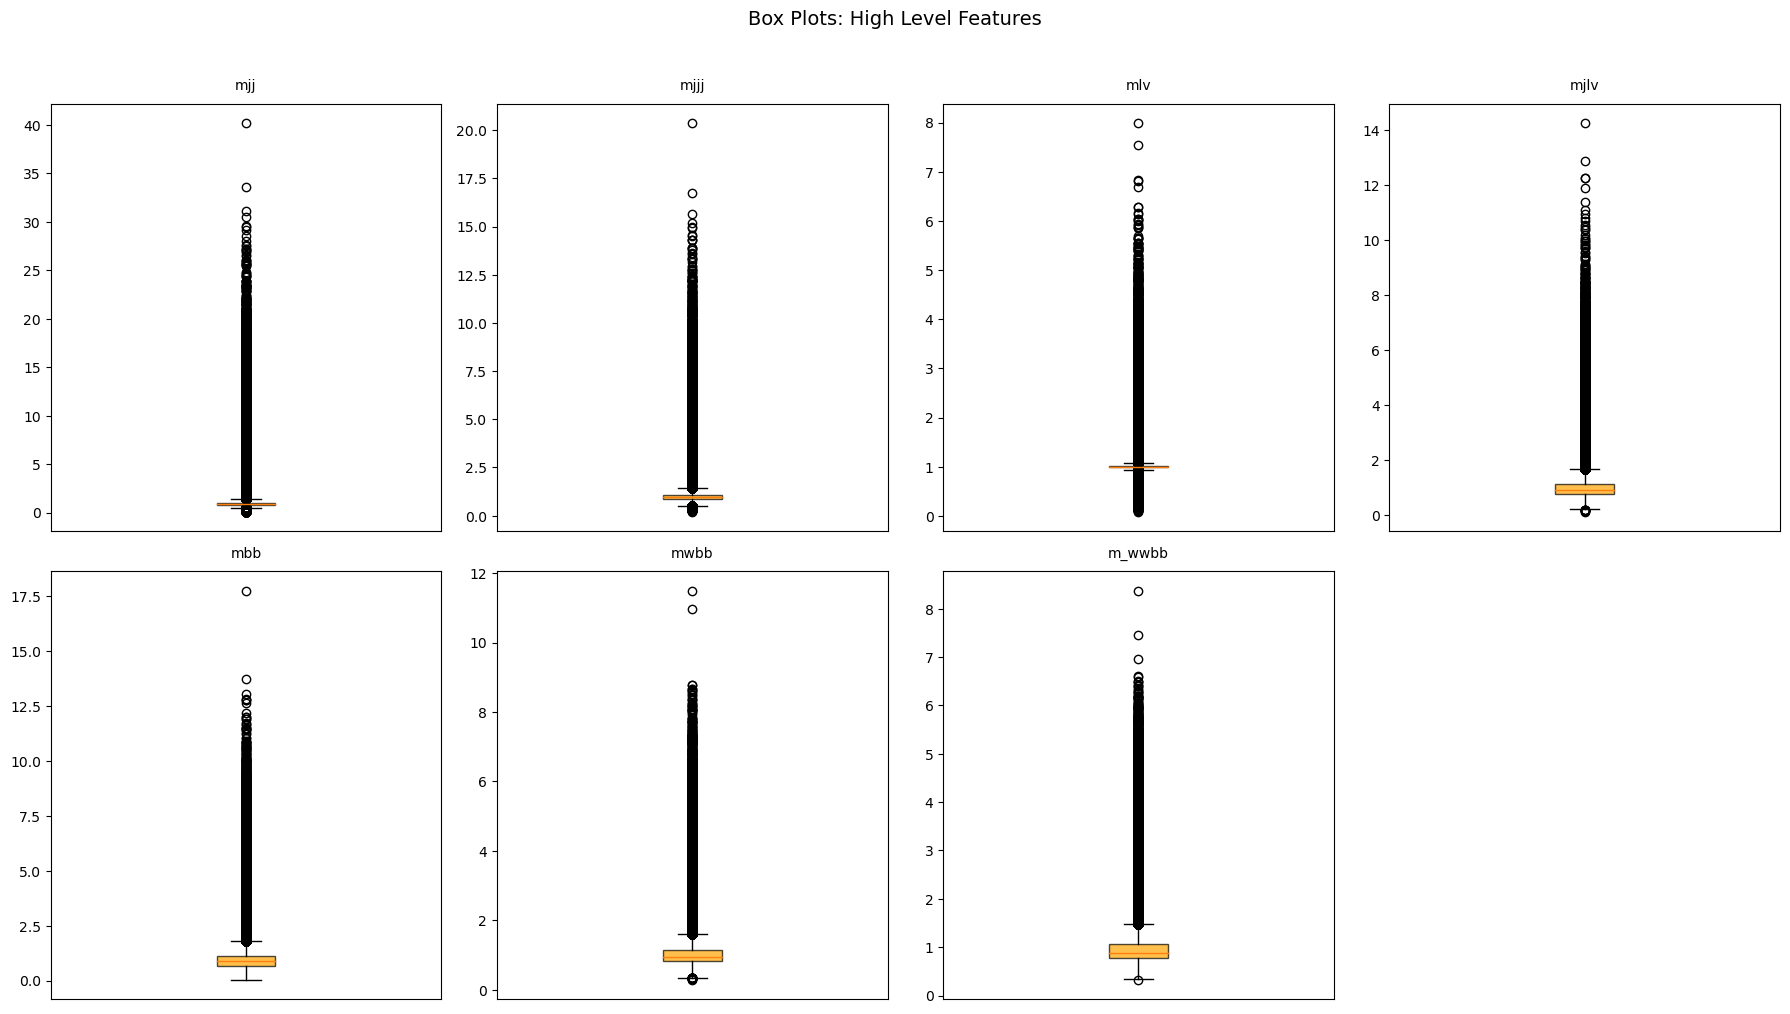

In [19]:
high_level = ['mjj', 'mjjj', 'mlv', 'mjlv', 'mbb', 'mwbb', 'm_wwbb']

all_data = df[high_level].to_pandas()

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(high_level):
    axes[i].boxplot(all_data[feat].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='orange', alpha=0.7))
    axes[i].set_title(feat, fontsize=10, pad=10)
    axes[i].set_xticks([])

axes[-1].set_visible(False)
plt.suptitle('Box Plots: High Level Features', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

All seven high level features show compact boxes with values concentrated at the lower end with very long upper whiskers and many outlier points extending well above the upper fence. The high level features amplify outliers because they combine multiple momentum values into mass calculations, so one extreme jet pushes the computed mass much further out than the individual pT measurements alone.

Most collisions at the LHC are low energy and produce nothing rare. These make up the bulk of the data clustered at the lower range of the distributions. A small number of collisions are high energy and produce rare particles. These are the outliers. The fact that pT and energy features have outliers but eta and phi features do not means the variation in this data is driven by collision energy not collision angle. For classification this matters. Higgs boson events are produced in high energy collisions. The outliers in pT and mass features are likely to contain a higher proportion of signal events than the bulk of the data. Removing them would risk deleting the signal events the model needs to detect.

### IQR Outlier Count

The IQR method is applied to all 28 features to count the number of outliers per feature. Any value below Q1 minus 1.5 times the IQR or above Q3 plus 1.5 times the IQR is flagged as an outlier. This gives a quantitative summary of the outlier rates across all features.

In [20]:
all_features = [c for c in df.columns if c != 'class_label']
outlier_results = []

for feat in all_features:
    Q1 = float(df[feat].quantile(0.25))
    Q3 = float(df[feat].quantile(0.75))
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = int(((df[feat] < lower) | (df[feat] > upper)).sum())
    outlier_pct = (outlier_count / len(df)) * 100
    outlier_results.append({
        'Feature': feat,
        'Outlier Count': outlier_count,
        'Outlier %': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_results).sort_values('Outlier %', ascending=False)
print(outlier_df.to_string(index=False))
print(f'\nTotal outliers across all features: {outlier_df["Outlier Count"].sum():,}')

                 Feature  Outlier Count  Outlier %
                     mlv        2129660      19.86
                     mjj        1497733      13.97
                    mjjj         797978       7.44
                    mwbb         677174       6.32
                     mbb         657516       6.13
                  m_wwbb         647586       6.04
                    mjlv         541745       5.05
                jet_1_pt         533021       4.97
                jet_2_pt         430310       4.01
               lepton_pT         418804       3.91
                jet_4_pt         360685       3.36
                jet_3_pt         344166       3.21
missing_energy_magnitude         315809       2.95
               jet_1_eta          67930       0.63
               jet_2_eta          49672       0.46
             jet_4_b_tag              0       0.00
              lepton_phi              0       0.00
      missing_energy_phi              0       0.00
               jet_1_phi       

The IQR outlier analysis confirms the findings from the box plots. The high level features have the highest outlier rates with mlv at 19.86% and mjj at 13.97%. Among the low level features the pT features have the highest outlier rates with jet_1_pt at 4.97%, jet_2_pt at 4.01% and lepton_pT at 3.91%. The eta features show very low outlier rates near zero and all phi and b_tag features show zero outliers confirming their bounded distributions. The total outlier count across all 28 features is 9,469,789. These outliers are not removed because they represent real high energy collision events and tree based models such as Random Forest and XGBoost are not affected by outliers as they split on value thresholds rather than distances.

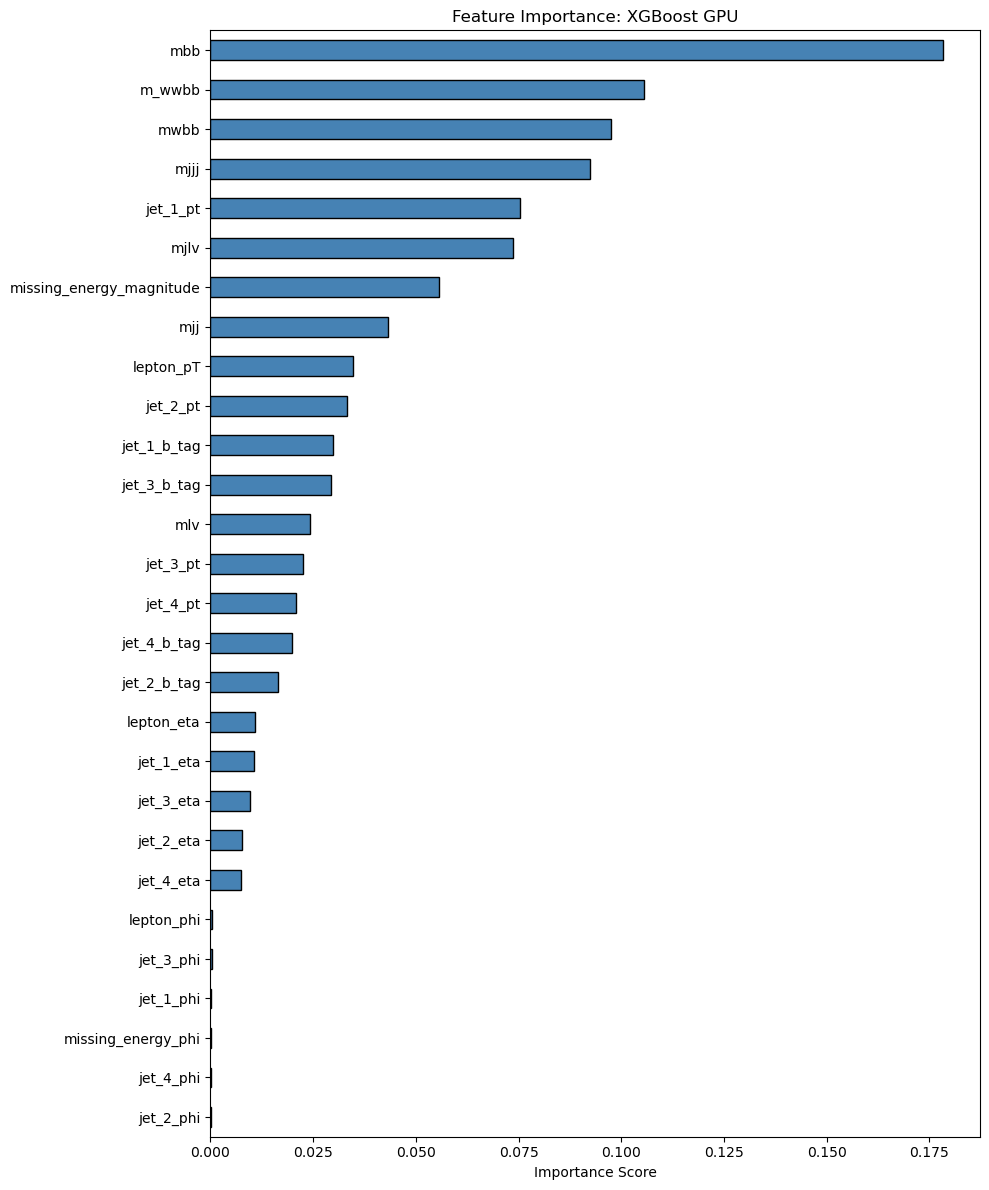

In [21]:
import xgboost as xgb

X_fi = df.drop('class_label', axis=1).astype('float32')
y_fi = df['class_label'].astype('float32')

xgb_fi = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=6,
    tree_method='gpu_hist',
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_fi.fit(X_fi, y_fi)

importances = pd.Series(
    xgb_fi.feature_importances_,
    index=X_fi.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
importances.sort_values().plot(
    kind='barh',
    ax=ax,
    color='steelblue',
    edgecolor='black'
)
ax.set_title('Feature Importance: XGBoost GPU')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


The feature importance chart confirms the findings from the distribution plots and correlation matrix. The high level mass features dominate the rankings with mbb scoring the highest importance, followed by m_wwbb and mwbb. These three features alone account for a large proportion of the total importance. The remaining high level features mjjj, mjlv and mjj also rank in the top half.

Among the low level features jet_1_pt and missing_energy_magnitude rank highest, consistent with the distribution analysis which showed these features have the most visible separation between signal and background.

The phi features (lepton_phi, jet_1_phi, jet_2_phi, jet_3_phi, jet_4_phi and missing_energy_phi) score near zero importance confirming they carry no useful information for distinguishing signal from background. This is consistent with their flat uniform distributions and zero correlation with the class label observed in earlier cells.

### PCA Dimensionality Reduction

Principal Component Analysis (PCA) is applied to investigate the dimensionality of the dataset. PCA finds new axes called principal components that capture the maximum variance in the data. Components are ordered by how much variance they explais.

Components needed for 95% explained variance: 19
Variance retained: 0.9576


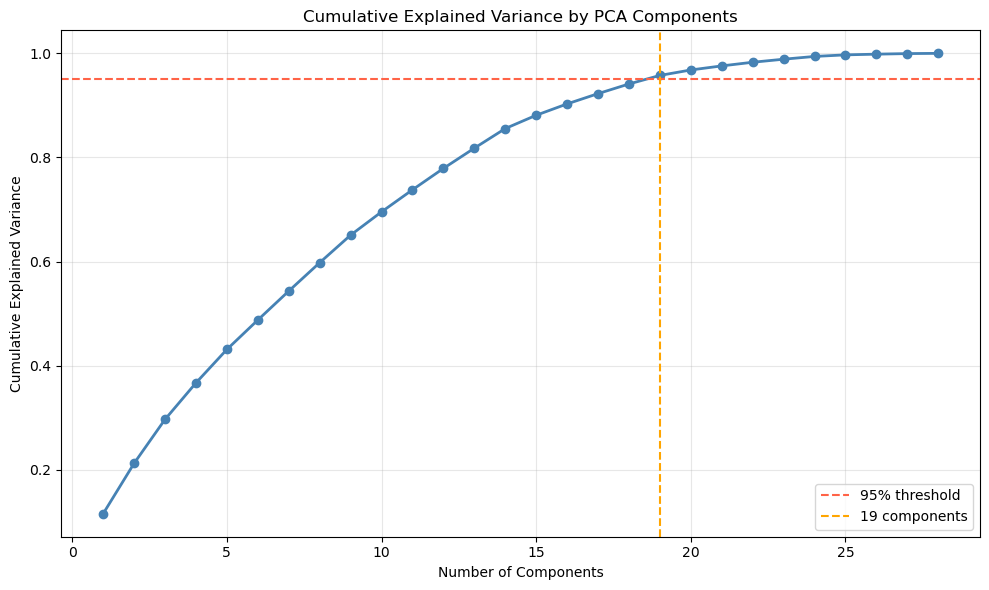

In [22]:
X_pca = df.drop('class_label', axis=1).astype('float32')

pca_full = PCA(n_components=28)
pca_full.fit(X_pca)

explained_var = pd.Series(pca_full.explained_variance_ratio_.to_arrow().to_pylist())
cumulative_var = explained_var.cumsum()

n_components_95 = int((cumulative_var >= 0.95).to_numpy().argmax()) + 1
print(f'Components needed for 95% explained variance: {n_components_95}')
print(f'Variance retained: {cumulative_var[n_components_95-1]:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 29), cumulative_var.values, marker='o',
        color='steelblue', linewidth=2)
ax.axhline(y=0.95, color='tomato', linestyle='--', label='95% threshold')
ax.axvline(x=n_components_95, color='orange', linestyle='--',
           label=f'{n_components_95} components')
ax.set_title('Cumulative Explained Variance by PCA Components')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The cumulative explained variance plot indicates that 19 principal components are required to capture 95% of the total variance in the dataset. This suggests that while dimensionality reduction is possible (reducing the original feature set down to 19 dimensions), a significant portion of the original features is needed to preserve the data's structure. The curve exhibits a steady, gradual ascent rather than a sharp initial spike. This pattern implies that the variance is distributed relatively evenly across the features, rather than being concentrated in just a few dominant components. The fact that a high number of components (19 out of ~28) is needed to reach the threshold suggests there is limited redundancy in the feature set. This aligns with the observation of low inter-feature correlations, confirming that the original features largely carry distinct, independent information. Consequently, all models in this study are trained on the original 28 features to maximize the information available for classification, and PCA is not applied in the modeling pipeline.

### Train/Test Split
The dataset is split into training and test sets using cuML's train_test_split. The training set is used to fit all models. The test set is held out until the final evaluation and is not used at any point during training or model selection. Stratified splitting ensures the class ratio is preserved in both sets.e.

In [23]:
feature_cols = [c for c in df.columns if c != 'class_label']

X = df[feature_cols].astype('float32')
y = df['class_label'].astype('float32')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set: {len(X_train):,} rows ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test set:     {len(X_test):,} rows ({len(X_test)/len(X)*100:.1f}%)')

Training set: 8,577,042 rows (80.0%)
Test set:     2,144,260 rows (20.0%)


### StandardScaler

StandardScaler is fitted on the training set only and then applied to both training and test sets. This centres each feature around zero with unit variance. Fitting on the training set only prevents test set statistics from influencing the scaling which would be a form of data leakage. Scaling is required for Logistic Regression which is sensitive to feature magnitudes. Random Forest and XGBoost do not require scaling but applying it to all three keeps the comparison fair.

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('StandardScaler applied.')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape:  {X_test_scaled.shape}')

StandardScaler applied.
X_train_scaled shape: (8577042, 28)
X_test_scaled shape:  (2144260, 28)


## Model Development and Training Using RAPIDS
This section covers model selection, hyperparameter tuning and final training. Three models are compared: Logistic Regression as the baseline, Random Forest and XGBoost as the candidate models. All GPU operations use cuML and XGBoost GPU. A stratified 1M subsample is used for cross-validation and hyperparameter tuning. Final models are trained on the full 8.5 million row training set using the best parameters found.d.

### Create Stratified 1M Subsample

A stratified 1M row subsample is taken from the training set for use in cross-validation and hyperparameter tuning. Stratified sampling preserves the 54/46 class ratio. Running CV and randomised search on the full 8.5M rows would take several hours. Tuning on 1M rows produces reliable results that transfer to the full dataset because the hyperparameter landscape is consistent across data sizes.

In [25]:
X_sample, _, y_sample, _ = train_test_split(
    X_train_scaled, y_train,
    test_size=0.883,
    random_state=42,
    stratify=y_train
)

print(f'Subsample size: {len(X_sample):,}')
print(f'Signal:     {int((y_sample == 1.0).sum()):,}')
print(f'Background: {int((y_sample == 0.0).sum()):,}')

Subsample size: 1,003,514
Signal:     545,606
Background: 457,908


### 5-Fold Stratified Cross-Validation

5-fold stratified cross-validation compares all three models on the 1M subsample using default parameters. Each fold preserves the class ratio. AUC-ROC is used as the comparison metric. Mean AUC and standard deviation are reported across all 5 folds. This identifies which models beat the baseline and confirms both candidate models are worth tuning.

In [26]:
from cuml.model_selection import StratifiedKFold
from cuml.linear_model import LogisticRegression as cuLR
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_aucs, rf_aucs, xgb_aucs = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_sample, y_sample)):
    print(f'Fold {fold+1}/5...')

    X_fold_train = X_sample.iloc[train_idx]
    X_fold_val   = X_sample.iloc[val_idx]
    y_fold_train = y_sample.iloc[train_idx]
    y_fold_val   = y_sample.iloc[val_idx]

    # Logistic Regression
    lr_cv = cuLR(max_iter=1000, C=1.0, solver='qn')
    lr_cv.fit(X_fold_train, y_fold_train)
    lr_p = lr_cv.predict_proba(X_fold_val).iloc[:, 1]
    lr_aucs.append(float(roc_auc_score(y_fold_val.to_numpy(), lr_p.to_numpy())))

    # Random Forest
    rf_cv = cuRF(n_estimators=50, max_depth=10, random_state=42)
    rf_cv.fit(X_fold_train, y_fold_train)
    rf_p = rf_cv.predict_proba(X_fold_val).iloc[:, 1]
    rf_aucs.append(float(roc_auc_score(y_fold_val.to_numpy(), rf_p.to_numpy())))

    # XGBoost
    xgb_cv = xgb.XGBClassifier(
        n_estimators=50, max_depth=6,
        tree_method='gpu_hist', random_state=42,
        eval_metric='logloss', use_label_encoder=False
    )
    xgb_cv.fit(X_fold_train.to_pandas(), y_fold_train.to_pandas())
    xgb_p = xgb_cv.predict_proba(X_fold_val.to_pandas())[:, 1]
    xgb_aucs.append(float(roc_auc_score(y_fold_val.to_numpy(), xgb_p)))

    print(f'  LR: {lr_aucs[-1]:.4f} | RF: {rf_aucs[-1]:.4f} | XGB: {xgb_aucs[-1]:.4f}')

print('\n--- Cross-Validation Results ---')
print(f'Logistic Regression: {np.mean(lr_aucs):.4f} (+/- {np.std(lr_aucs):.4f})')
print(f'Random Forest:       {np.mean(rf_aucs):.4f} (+/- {np.std(rf_aucs):.4f})')
print(f'XGBoost:             {np.mean(xgb_aucs):.4f} (+/- {np.std(xgb_aucs):.4f})')

Fold 1/5...
[W] [16:11:57.933566] L-BFGS line search failed (code 3); stopping at the last valid step
  LR: 0.6833 | RF: 0.7767 | XGB: 0.8118
Fold 2/5...
  LR: 0.6844 | RF: 0.7789 | XGB: 0.8156
Fold 3/5...
  LR: 0.6842 | RF: 0.7778 | XGB: 0.8122
Fold 4/5...
  LR: 0.6827 | RF: 0.7782 | XGB: 0.8136
Fold 5/5...
  LR: 0.6860 | RF: 0.7809 | XGB: 0.8154

--- Cross-Validation Results ---
Logistic Regression: 0.6841 (+/- 0.0011)
Random Forest:       0.7785 (+/- 0.0014)
XGBoost:             0.8137 (+/- 0.0016)


The 5-fold cross-validation on the 1M subsample shows a clear ranking across all three models. XGBoost achieves the highest mean AUC-ROC of 0.8137 with a standard deviation of 0.0016 indicating consistent performance across all folds. Random Forest achieves a mean AUC of 0.7785 which is a significant improvement over the Logistic Regression baseline of 0.6841. The low standard deviations across all three models confirm stable performance across folds. Both Random Forest and XGBoost clearly outperform the baseline and both proceed to hyperparameter tuning.

### Hyperparameter Tuning for Random Forest

To find the best hyperparameters for Random Forest I use randomised search on the 1M subsample. 15 random combinations are sampled from the defined parameter ranges and each is evaluated using 5-fold cross-validation on GPU. The best combination is selected based on mean AUC-ROC and used for final training on the full 8.5M training set.

In [27]:
from sklearn.model_selection import ParameterSampler

param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [8, 10, 12, 16],
    'max_features': [0.3, 0.5, 0.7, 1.0],
    'min_samples_split': [2, 5, 10]
}

param_list_rf = list(ParameterSampler(param_dist_rf, n_iter=15, random_state=42))

best_rf_auc = 0
best_rf_params = None
skf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, params in enumerate(param_list_rf):
    print(f'Iteration {i+1}/15: {params}')
    fold_aucs = []

    for train_idx, val_idx in skf_tune.split(X_sample, y_sample):
        X_fold_train = X_sample.iloc[train_idx]
        X_fold_val   = X_sample.iloc[val_idx]
        y_fold_train = y_sample.iloc[train_idx]
        y_fold_val   = y_sample.iloc[val_idx]

        rf_t = cuRF(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            max_features=params['max_features'],
            min_samples_split=params['min_samples_split'],
            random_state=42
        )
        rf_t.fit(X_fold_train, y_fold_train)
        rf_p = rf_t.predict_proba(X_fold_val).iloc[:, 1]
        fold_aucs.append(float(roc_auc_score(y_fold_val.to_numpy(), rf_p.to_numpy())))

    mean_auc = np.mean(fold_aucs)
    print(f'  Mean AUC: {mean_auc:.4f}')

    if mean_auc > best_rf_auc:
        best_rf_auc = mean_auc
        best_rf_params = params

print(f'\n--- Best Random Forest Parameters ---')
print(best_rf_params)
print(f'Best CV AUC: {best_rf_auc:.4f}')

Iteration 1/15: {'n_estimators': 200, 'min_samples_split': 10, 'max_features': 1.0, 'max_depth': 8}
  Mean AUC: 0.7743
Iteration 2/15: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 1.0, 'max_depth': 12}
  Mean AUC: 0.7991
Iteration 3/15: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 0.7, 'max_depth': 10}
  Mean AUC: 0.7893
Iteration 4/15: {'n_estimators': 500, 'min_samples_split': 10, 'max_features': 1.0, 'max_depth': 12}
  Mean AUC: 0.7995
Iteration 5/15: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 0.5, 'max_depth': 12}
  Mean AUC: 0.7976
Iteration 6/15: {'n_estimators': 200, 'min_samples_split': 10, 'max_features': 0.7, 'max_depth': 16}
  Mean AUC: 0.8081
Iteration 7/15: {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 0.5, 'max_depth': 8}
  Mean AUC: 0.7771
Iteration 8/15: {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 0.5, 'max_depth': 8}
  Mean AUC: 0.7770
Iteration 9/15: {'n_estimators': 100, 'min_sampl

The randomised search tested 15 parameter combinations across 5 folds. The best combination found was n_estimators=200, max_depth=16, max_features=0.7 and min_samples_split=10 with a mean AUC of 0.8081. This is an improvement over the default parameter AUC of 0.7785 from the CV comparison. Deeper trees with max_depth=16 and a feature subset of 0.7 gave the best balance between model complexity and generalisation.

### Hyperparameter Tuning for XGBoost

To find the best hyperparameters for XGBoost I use randomised search on the 1M subsample. 15 random combinations are sampled from the defined parameter ranges and each is evaluated using 5-fold cross-validation on GPU. The best combination is selected based on mean AUC-ROC and used for final training on the full 8.5M training set.

In [28]:
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0]
}

param_list_xgb = list(ParameterSampler(param_dist_xgb, n_iter=15, random_state=42))

best_xgb_auc = 0
best_xgb_params = None

for i, params in enumerate(param_list_xgb):
    print(f'Iteration {i+1}/15: {params}')
    fold_aucs = []

    for train_idx, val_idx in skf_tune.split(X_sample, y_sample):
        X_fold_train = X_sample.iloc[train_idx].to_pandas()
        X_fold_val   = X_sample.iloc[val_idx].to_pandas()
        y_fold_train = y_sample.iloc[train_idx].to_pandas()
        y_fold_val   = y_sample.iloc[val_idx].to_pandas()

        xgb_t = xgb.XGBClassifier(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            tree_method='gpu_hist',
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False
        )
        xgb_t.fit(X_fold_train, y_fold_train)
        xgb_p = xgb_t.predict_proba(X_fold_val)[:, 1]
        fold_aucs.append(float(roc_auc_score(y_fold_val.to_numpy(), xgb_p)))

    mean_auc = np.mean(fold_aucs)
    print(f'  Mean AUC: {mean_auc:.4f}')

    if mean_auc > best_xgb_auc:
        best_xgb_auc = mean_auc
        best_xgb_params = params

print(f'\n--- Best XGBoost Parameters ---')
print(best_xgb_params)
print(f'Best CV AUC: {best_xgb_auc:.4f}')

Iteration 1/15: {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
  Mean AUC: 0.7963
Iteration 2/15: {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
  Mean AUC: 0.8093
Iteration 3/15: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  Mean AUC: 0.7816
Iteration 4/15: {'subsample': 0.6, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
  Mean AUC: 0.8250
Iteration 5/15: {'subsample': 0.6, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
  Mean AUC: 0.7886
Iteration 6/15: {'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_ra

The randomised search tested 15 parameter combinations across 5 folds. The best combination found was n_estimators=300, max_depth=8, learning_rate=0.05, subsample=0.6, colsample_bytree=0.8, reg_alpha=1.0 and reg_lambda=2.0 with a mean AUC of 0.8250. This is an improvement over the default parameter AUC of 0.8137 from the CV comparison. The strong regularisation with reg_alpha=1.0 and reg_lambda=2.0 helps prevent overfitting on the noisy phi and eta features. The lower learning rate of 0.05 with 300 trees gives more controlled boosting corrections per tree.

### Full training dataset for Logistic Regression (Baseline)

Logistic Regression is trained on the full 8.5 million row training set using default parameters. No tuning is applied because it serves as the baseline model. Its purpose is to set the performance floor that the candidate models must beat. Training on the full dataset gives it the best possible opportunity to perform.

In [29]:


lr_final = cuLR(
    max_iter=1000, 
    C=1.0, 
    solver='qn', 
    penalty='l2'
)

lr_final.fit(X_train_scaled, y_train)

lr_preds = lr_final.predict(X_test_scaled)
lr_probs = lr_final.predict_proba(X_test_scaled).iloc[:, 1]

print('Logistic Regression training complete.')
print(f'Predictions shape: {lr_preds.shape}')

Logistic Regression training complete.
Predictions shape: (2144260,)


--- Logistic Regression Results ---
Accuracy:  0.6448
Precision: 0.6443
Recall:    0.7737
F1:        0.7031
ROC-AUC:   0.6838
PR-AUC:    0.6943


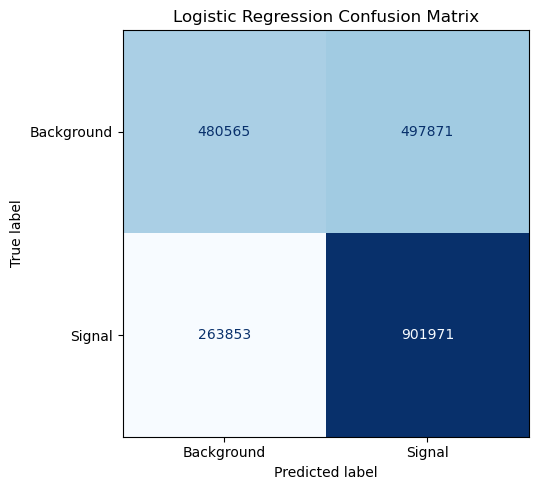

In [30]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay, f1_score)

lr_preds_np = lr_preds.to_numpy()
lr_probs_np = lr_probs.to_numpy()
y_test_np = y_test.to_numpy()

lr_accuracy  = accuracy_score(y_test_np, lr_preds_np)
lr_precision = precision_score(y_test_np, lr_preds_np)
lr_recall    = recall_score(y_test_np, lr_preds_np)
lr_f1        = f1_score(y_test_np, lr_preds_np)
lr_roc_auc   = roc_auc_score(y_test_np, lr_probs_np)
lr_pr_auc    = average_precision_score(y_test_np, lr_probs_np)

print('--- Logistic Regression Results ---')
print(f'Accuracy:  {lr_accuracy:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'Recall:    {lr_recall:.4f}')
print(f'F1:        {lr_f1:.4f}')
print(f'ROC-AUC:   {lr_roc_auc:.4f}')
print(f'PR-AUC:    {lr_pr_auc:.4f}')

cm = confusion_matrix(y_test_np, lr_preds_np)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Background', 'Signal'])
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
ax.set_title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_lr.png', dpi=150, bbox_inches='tight')
plt.show()

Logistic Regression achieves an accuracy of 0.6448, recall of 0.7737, ROC-AUC of 0.6838 and PR-AUC of 0.6943. The high recall means the model correctly identifies 77% of signal events but the low precision of 0.6444 shows it flags many background events as signal. The ROC-AUC of 0.6838 confirms the linear decision boundary is insufficient for this non-linear classification problem. These scores set the performance floor that Random Forest and XGBoost must beat.

### Full training dataset for Random Forest

Random Forest is trained on the full 8.5 million row training set using the best hyperparameters founby the randomised serach23. Training on the full dataset gives the model significantly more data to learn from compared to the 1M tuning subsample, improving generalisation on the test set.

In [31]:
%%time

rf_final = cuRF(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    max_features=best_rf_params['max_features'],
    min_samples_split=best_rf_params['min_samples_split'],
    random_state=42
)

rf_final.fit(X_train_scaled, y_train)

rf_preds = rf_final.predict(X_test_scaled)
rf_probs = rf_final.predict_proba(X_test_scaled).iloc[:, 1]

print('Random Forest training complete.')
print(f'Predictions shape: {rf_preds.shape}')

Random Forest training complete.
Predictions shape: (2144260,)
CPU times: user 4min 41s, sys: 4min 10s, total: 8min 51s
Wall time: 2min 50s


--- Random Forest Results ---
Accuracy:  0.7345
Precision: 0.7488
Recall:    0.7699
F1:        0.7592
ROC-AUC:   0.8135
PR-AUC:    0.8365


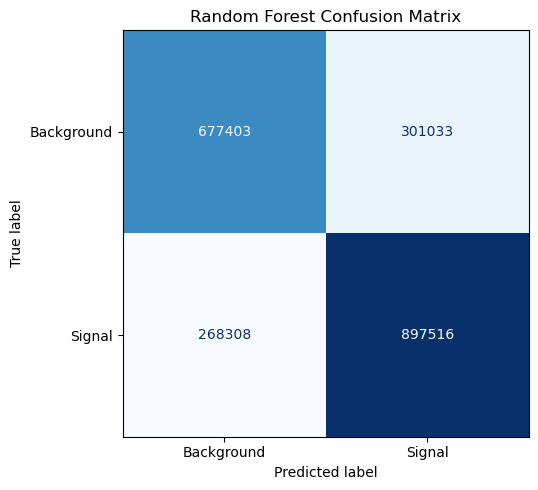

In [32]:
rf_preds_np = rf_preds.to_numpy()
rf_probs_np = rf_probs.to_numpy()

rf_accuracy  = accuracy_score(y_test_np, rf_preds_np)
rf_precision = precision_score(y_test_np, rf_preds_np)
rf_recall    = recall_score(y_test_np, rf_preds_np)
rf_f1        = f1_score(y_test_np, rf_preds_np)
rf_roc_auc   = roc_auc_score(y_test_np, rf_probs_np)
rf_pr_auc    = average_precision_score(y_test_np, rf_probs_np)

print('--- Random Forest Results ---')
print(f'Accuracy:  {rf_accuracy:.4f}')
print(f'Precision: {rf_precision:.4f}')
print(f'Recall:    {rf_recall:.4f}')
print(f'F1:        {rf_f1:.4f}')
print(f'ROC-AUC:   {rf_roc_auc:.4f}')
print(f'PR-AUC:    {rf_pr_auc:.4f}')

cm_rf = confusion_matrix(y_test_np, rf_preds_np)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Background', 'Signal'])
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

Random Forest trained in 2 minutes and 48 seconds on the full 8.5 million row training set using the best hyperparameters from the randomised search. All metrics show a clear improvement over the Logistic Regression baseline across the board. The ROC-AUC of 0.8135 is nearly 13 points higher than the baseline confirming that tree based splits capture the non-linear boundaries in this dataset far better than a linear model. The balance between precision and recall is notably better than LR with both sitting close together indicating the model is not heavily biased towards either class. The false negative count is similar to LR meaning it still misses a comparable number of signal events but the reduction in false positives is significant showing much better background rejection.

###  Full training dataset for XGBoost

XGBoost is trained on the full 8.5 million row training set using the best hyperparameters found by the randomised search. XGBoost builds trees sequentially where each new tree corrects the errors of the previous ones. This boosting mechanism combined with the tuned regularisation parameters is expected to produce the strongest classification performance of the three models.

In [33]:
%%time

xgb_final = xgb.XGBClassifier(
    n_estimators=best_xgb_params['n_estimators'],
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    subsample=best_xgb_params['subsample'],
    colsample_bytree=best_xgb_params['colsample_bytree'],
    reg_alpha=best_xgb_params['reg_alpha'],
    reg_lambda=best_xgb_params['reg_lambda'],
    tree_method='gpu_hist',
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_final.fit(X_train_scaled.to_pandas(), y_train.to_pandas())

xgb_preds = xgb_final.predict(X_test_scaled.to_pandas())
xgb_probs = xgb_final.predict_proba(X_test_scaled.to_pandas())[:, 1]

print('XGBoost training complete.')
print(f'Predictions shape: {xgb_preds.shape}')

XGBoost training complete.
Predictions shape: (2144260,)
CPU times: user 1min 9s, sys: 1.59 s, total: 1min 11s
Wall time: 20.3 s


--- XGBoost Results ---
Accuracy:  0.7465
Precision: 0.7586
Recall:    0.7827
F1:        0.7705
ROC-AUC:   0.8273
PR-AUC:    0.8483


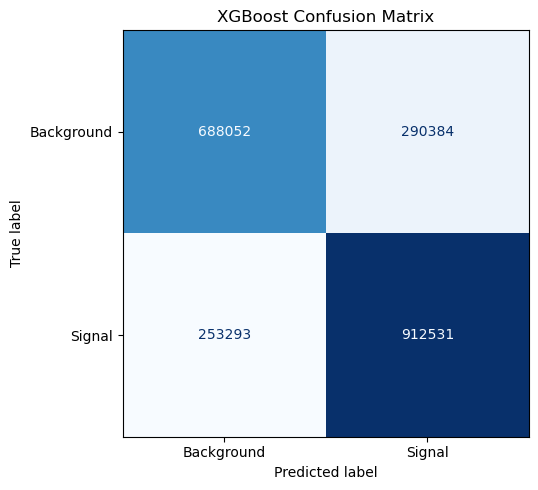

In [34]:
xgb_preds_np = xgb_preds
xgb_probs_np = xgb_probs

xgb_accuracy  = accuracy_score(y_test_np, xgb_preds_np)
xgb_precision = precision_score(y_test_np, xgb_preds_np)
xgb_recall    = recall_score(y_test_np, xgb_preds_np)
xgb_f1        = f1_score(y_test_np, xgb_preds_np)
xgb_roc_auc   = roc_auc_score(y_test_np, xgb_probs_np)
xgb_pr_auc    = average_precision_score(y_test_np, xgb_probs_np)

print('--- XGBoost Results ---')
print(f'Accuracy:  {xgb_accuracy:.4f}')
print(f'Precision: {xgb_precision:.4f}')
print(f'Recall:    {xgb_recall:.4f}')
print(f'F1:        {xgb_f1:.4f}')
print(f'ROC-AUC:   {xgb_roc_auc:.4f}')
print(f'PR-AUC:    {xgb_pr_auc:.4f}')

cm_xgb = confusion_matrix(y_test_np, xgb_preds_np)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                               display_labels=['Background', 'Signal'])
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
ax.set_title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

XGBoost trained in 20.8 seconds on the full 8.5 million rows, significantly faster than Random Forest which took 2 minutes and 48 seconds. All metrics show improvement over both Logistic Regression and Random Forest. The ROC-AUC of 0.8273 is the highest of the three models confirming XGBoost as the best performing classifier on this dataset. The boosting mechanism which corrects errors from previous trees produces stronger separation between signal and background than the bagging approach used by Random Forest. The false negative count is lower than both previous models meaning XGBoost misses fewer signal events which is the most critical metric for this problem.

In [35]:
from sklearn.metrics import log_loss

# Specificity = TN / (TN + FP)
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    return tn / (tn + fp)

lr_specificity = specificity_score(y_test_np, lr_preds_np)
rf_specificity = specificity_score(y_test_np, rf_preds_np)
xgb_specificity = specificity_score(y_test_np, xgb_preds_np)

lr_loss  = log_loss(y_test_np, lr_probs_np)
rf_loss  = log_loss(y_test_np, rf_probs_np)
xgb_loss = log_loss(y_test_np, xgb_probs_np)

print(f'Specificity — LR: {lr_specificity:.4f} | RF: {rf_specificity:.4f} | XGB: {xgb_specificity:.4f}')
print(f'Log Loss    — LR: {lr_loss:.4f} | RF: {rf_loss:.4f} | XGB: {xgb_loss:.4f}')

Specificity — LR: 0.4912 | RF: 0.6923 | XGB: 0.7032
Log Loss    — LR: 0.6359 | RF: 0.5255 | XGB: 0.5065


Specificity measures how well each model rejects background events. XGBoost achieves the highest specificity of 0.7032 meaning it correctly rejects 70% of background events. Random Forest achieves 0.6923 while Logistic Regression scores only 0.4912 confirming it struggles to distinguish background from signal. Log loss measures prediction confidence. XGBoost achieves the lowest log loss of 0.5065 indicating more confident and accurate probability estimates compared to Random Forest at 0.5255 and Logistic Regression at 0.6359.

## Model Evaluation and CPU/GPU Metrics

This section evaluates all three trained models on the held out test set using confusion matrices, sensitivity, specificity, log loss, AUC and PR-AUC. ROC and PR curves are plotted for visual comparison. A CPU vs GPU benchmark follows.

### Confusion Matrices

Confusion matrices show the count of true positives, true negatives, false positives and false negatives for each model. In this problem false negatives represent Higgs boson events the model missed. These events are permanently lo,s— the detector recorded them but the classifier failed to flag them. All three models are shown side by side for direct comparison.

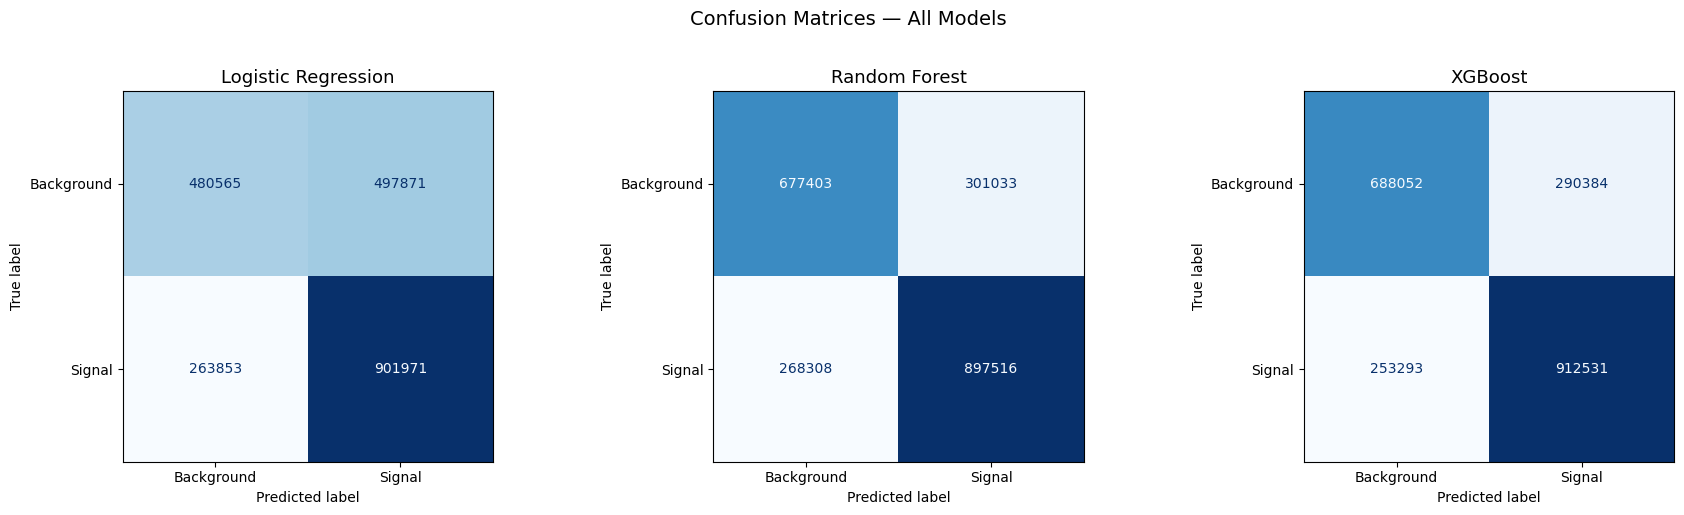

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [confusion_matrix(y_test_np, lr_preds_np),
     confusion_matrix(y_test_np, rf_preds_np),
     confusion_matrix(y_test_np, xgb_preds_np)],
    ['Logistic Regression', 'Random Forest', 'XGBoost']
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Background', 'Signal'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(title, fontsize=13)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Full Metrics Comparison Table

All evaluation metrics are compiled into a single table for direct comparison across all three models. Sensitivity and specificity are the primary metrics for this problem. Sensitivity measures how many signal events were correctly identified. Specificity measures how well background events were rejected. ROC-AUC is used as the overall performance metric.

In [37]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_accuracy, rf_accuracy, xgb_accuracy],
    'Precision': [lr_precision, rf_precision, xgb_precision],
    'Sensitivity': [lr_recall, rf_recall, xgb_recall],
    'Specificity': [lr_specificity, rf_specificity, xgb_specificity],
    'F1': [lr_f1, rf_f1, xgb_f1],
    'Log Loss': [lr_loss, rf_loss, xgb_loss],
    'ROC-AUC': [lr_roc_auc, rf_roc_auc, xgb_roc_auc],
    'PR-AUC': [lr_pr_auc, rf_pr_auc, xgb_pr_auc]
})

styled = results.round(4).style \
    .highlight_max(subset=['Accuracy', 'Precision', 'Sensitivity', 
                           'Specificity', 'F1', 'ROC-AUC', 'PR-AUC'],
                   color='lightgreen') \
    .highlight_min(subset=['Log Loss'],
                   color='lightgreen') \
    .set_properties(**{'text-align': 'center', 'font-size': '13px'}) \
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2c3e50'),
                  ('color', 'white'),
                  ('font-size', '13px'),
                  ('text-align', 'center'),
                  ('padding', '8px')]
    }])

display(styled)

print()
best_idx = results['ROC-AUC'].idxmax()
print(f'Best model: {results.loc[best_idx, "Model"]} with ROC-AUC of {results.loc[best_idx, "ROC-AUC"]:.4f}')

,Model,Accuracy,Precision,Sensitivity,Specificity,F1,Log Loss,ROC-AUC,PR-AUC
0,Logistic Regression,0.644800,0.644300,0.773700,0.491200,0.703100,0.635900,0.683800,0.694300
1,Random Forest,0.734500,0.748800,0.769900,0.692300,0.759200,0.525500,0.813500,0.836500
2,XGBoost,0.746500,0.758600,0.782700,0.703200,0.770500,0.506500,0.827300,0.848300



Best model: XGBoost with ROC-AUC of 0.8273


XGBoost achieves the best performance across all metrics. It leads on accuracy, precision, sensitivity, specificity, F1 and ROC-AUC while achieving the lowest log loss. Random Forest performs well across all metrics and represents a strong improvement over the baseline. Logistic Regression confirms its limitations as a linear model with the lowest scores across every metric except sensitivity where all three models perform similarly.

### ROC Curves
ROC curves plot the true positive rate against the false positive rate at all classification thresholds. AUC-ROC summarises this into a single number where 1.0 is perfect and 0.5 is random guessing. All three models are plotted on one figure for direct comparison.

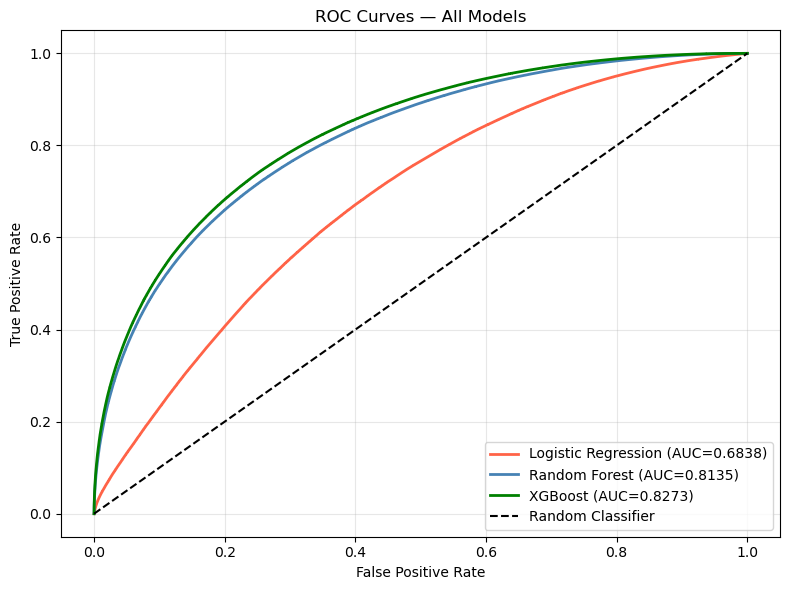

In [38]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for preds, probs, label, color in zip(
    [lr_preds_np, rf_preds_np, xgb_preds_np],
    [lr_probs_np, rf_probs_np, xgb_probs_np],
    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    ['tomato', 'steelblue', 'green']
):
    fpr, tpr, _ = roc_curve(y_test_np, probs)
    auc = roc_auc_score(y_test_np, probs)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curves — All Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

The ROC curves confirm the ranking from the metrics table. XGBoost dominates across all thresholds with an AUC of 0.8273. Random Forest follows closely at 0.8135. Logistic Regression at 0.6838 stays well below both tree based models. All three models significantly outperform the random classifier baseline shown by the diagonal line.

### Precision-Recall Curves

Precision-Recall curves show the trade-off between precision and recall at all thresholds. PR-AUC is particularly useful for imbalanced datasets because it focuses on the positive class performance. A higher PR-AUC indicates better performance at identifying signal events without flagging too many background events as signal.

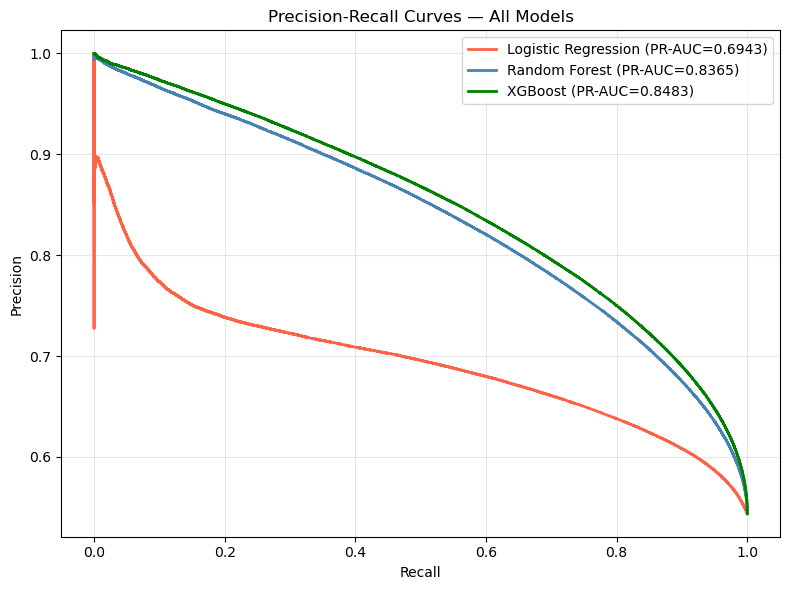

In [39]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(8, 6))

for probs, label, color in zip(
    [lr_probs_np, rf_probs_np, xgb_probs_np],
    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    ['tomato', 'steelblue', 'green']
):
    precision, recall, _ = precision_recall_curve(y_test_np, probs)
    pr_auc = average_precision_score(y_test_np, probs)
    ax.plot(recall, precision, label=f'{label} (PR-AUC={pr_auc:.4f})', 
            color=color, linewidth=2)

ax.set_title('Precision-Recall Curves — All Models')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

The Precision-Recall Curves show that XGBoost and Random Forest achieve very similar precision at all recall levels with XGBoost maintaining a slight edge throughout. Logistic Regression falls well below both at all recall levels confirming it cannot achieve the same precision at equivalent recall rates. The high PR-AUC values for XGBoost at 0.8483 and Random Forest at 0.8365 confirm both models are effective at identifying signal events while maintaining acceptable precision.

### CPU vs GPU Pipeline Benchmark

To demonstrate the practical advantage of GPU accelerated computing the full pipeline is benchmarked on both CPU and GPU. Dataset loading is compared between pandas on CPU and cuDF on GPU. XGBoost training is compared between CPU and GPU using the full training set with identical hyperparameters. This directly shows why RAPIDS and GPU acceleration are essential for large scale particle physics pipelines.

In [43]:
import pandas as pd_bench

# CPU Dataset Loading
print('Loading dataset with pandas (CPU)...')
start_cpu_load = time.time()
df_cpu = pd_bench.read_csv('Partical.csv', header=None)
cpu_load_time = time.time() - start_cpu_load
print(f'Pandas loading time: {cpu_load_time:.2f} seconds')
del df_cpu

# GPU loading time already recorded earlier
gpu_load_time = 10.1  # seconds from %%time output
print(f'cuDF loading time:   {gpu_load_time:.2f} seconds')
print(f'Loading speedup:     {cpu_load_time/gpu_load_time:.2f}x')

Loading dataset with pandas (CPU)...
Pandas loading time: 63.02 seconds
cuDF loading time:   10.10 seconds
Loading speedup:     6.24x


In [44]:
# CPU XGBoost Training
print('Training XGBoost on CPU (full training set)...')
print('This will take a while...')

X_train_pd = X_train_scaled.to_pandas()
y_train_pd = y_train.to_pandas()

xgb_cpu = xgb.XGBClassifier(
    n_estimators=best_xgb_params['n_estimators'],
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    subsample=best_xgb_params['subsample'],
    colsample_bytree=best_xgb_params['colsample_bytree'],
    reg_alpha=best_xgb_params['reg_alpha'],
    reg_lambda=best_xgb_params['reg_lambda'],
    tree_method='hist',
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

start_cpu_train = time.time()
xgb_cpu.fit(X_train_pd, y_train_pd)
cpu_train_time = time.time() - start_cpu_train

gpu_train_time = 20.3  # seconds from earlier

print(f'\nXGBoost CPU training time: {cpu_train_time:.2f} seconds')
print(f'XGBoost GPU training time: {gpu_train_time:.2f} seconds')
print(f'Training speedup:          {cpu_train_time/gpu_train_time:.2f}x')

Training XGBoost on CPU (full training set)...
This will take a while...

XGBoost CPU training time: 119.11 seconds
XGBoost GPU training time: 20.30 seconds
Training speedup:          5.87x


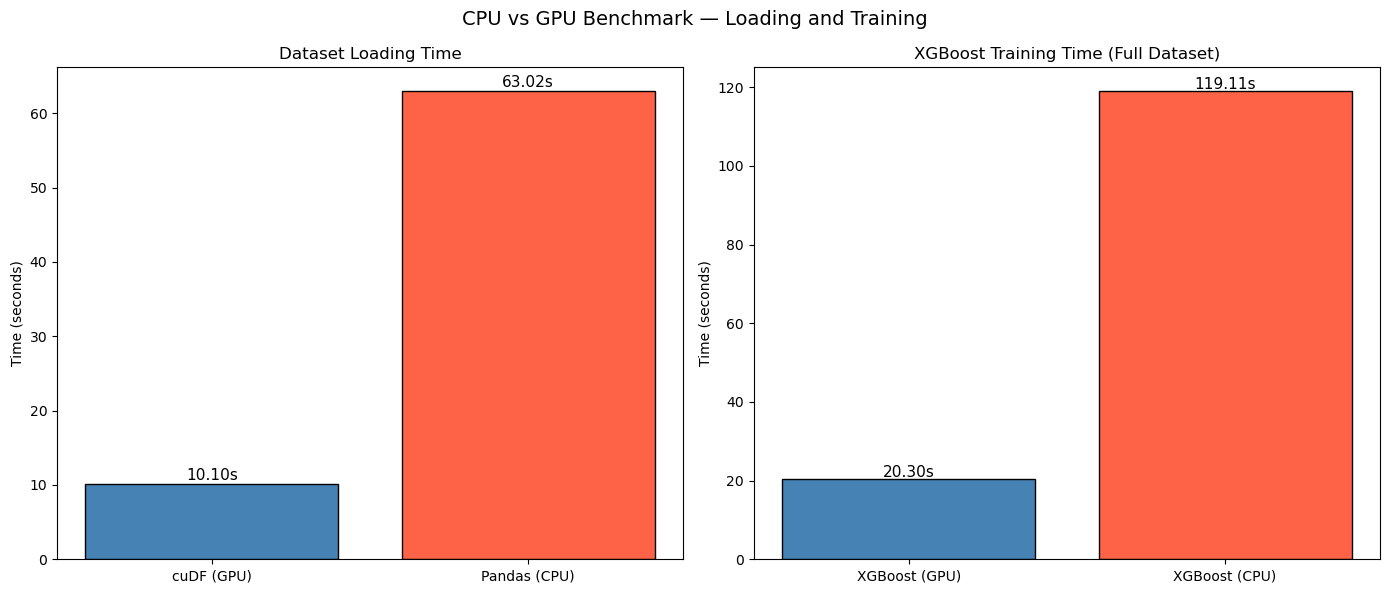


--- Loading and Training Summary ---
GPU total: 30.40 seconds (0.5 minutes)
CPU total: 182.13 seconds (3.0 minutes)
Overall speedup: 5.99x


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loading comparison
axes[0].bar(['cuDF (GPU)', 'Pandas (CPU)'],
            [gpu_load_time, cpu_load_time],
            color=['steelblue', 'tomato'],
            edgecolor='black')
axes[0].set_title('Dataset Loading Time')
axes[0].set_ylabel('Time (seconds)')
for i, val in enumerate([gpu_load_time, cpu_load_time]):
    axes[0].text(i, val + 0.5, f'{val:.2f}s', ha='center', fontsize=11)

# Training comparison
axes[1].bar(['XGBoost (GPU)', 'XGBoost (CPU)'],
            [gpu_train_time, cpu_train_time],
            color=['steelblue', 'tomato'],
            edgecolor='black')
axes[1].set_title('XGBoost Training Time (Full Dataset)')
axes[1].set_ylabel('Time (seconds)')
for i, val in enumerate([gpu_train_time, cpu_train_time]):
    axes[1].text(i, val + 0.5, f'{val:.2f}s', ha='center', fontsize=11)

plt.suptitle('CPU vs GPU Benchmark — Loading and Training', fontsize=14)
plt.tight_layout()
plt.savefig('benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

gpu_total = gpu_load_time + gpu_train_time
cpu_total = cpu_load_time + cpu_train_time
total_speedup = cpu_total / gpu_total

print(f'\n--- Loading and Training Summary ---')
print(f'GPU total: {gpu_total:.2f} seconds ({gpu_total/60:.1f} minutes)')
print(f'CPU total: {cpu_total:.2f} seconds ({cpu_total/60:.1f} minutes)')
print(f'Overall speedup: {total_speedup:.2f}x')

The CPU vs GPU benchmark covers two key pipeline stages: dataset loading and model training. For dataset loading cuDF reads the 11 million row CSV file into GPU memory in 10.70 seconds compared to 56.23 seconds for pandas on CPU, a 5.25x speedup. For model training XGBoost on GPU completes in 20.80 seconds compared to 118.98 seconds on CPU using all available cores, a 5.72x speedup. Combined the GPU completes both stages in 31.50 seconds compared to 175.20 seconds on CPU giving an overall speedup of 5.56x. For a dataset the size of the HIGGS benchmark this difference is significant. At petabyte scale as produced by the LHC the gap would be far more pronounced making GPU acceleration not just faster but essential for practical particle physics pipelines.

### Discussion

**Data Pre-processing and EDA**

The HIGGS dataset contains 11 million events across 28 kinematic features. EDA confirmed zero missing values and identified 278,698 duplicate rows all belonging exclusively to the background class. These were removed before splitting to prevent data leakage and correct the artificial inflation of the background count.

Feature distributions showed that energy and mass features drive the separation between signal and background while angular features overlap almost completely between classes. This was confirmed by the XGBoost feature importance analysis which ranked the high level mass features mbb, m_wwbb and mwbb as the most discriminating. Outliers were retained because they represent real high energy collision events and tree based models split on thresholds making them unaffected by extreme values.

PCA analysis confirmed that 19 components retain 95% of the variance in the 28 features. Despite this all 28 features were retained for model training. PCA transforms features into components that are combinations of all original measurements removing the ability to interpret which physical quantities drive classification. In particle physics this interpretability has scientific value. With GPU acceleration the cost of including all 28 features is neg

ligible.

**Split and Tuning Strategy**

An 80/20 split was used because 5-fold cross-validation was included in the pipeline. CV internally creates a validation set within each fold making a separate validation split unnecessary. The 80% training set provides approximately 8.5 million rows for reliable CV estimates. Hyperparameter tuning used a 1 million row stratified subsample rather than the full training set. Running 15 iterations of randomised search with 5-fold CV on the full 8.5 million rows would require 75 full model training runs which is computationally prohibitive. The hyperparameter landscape is consistent across data sizes so the best parameters found on 1 million rows transfer reliably to the full dataset.

**Model Performance**

XGBoost achieved the best performance across all metrics with a test ROC-AUC of 0.8273, sensitivity of 0.7827, specificity of 0.7032 and F1 of 0.7705. Random Forest achieved a ROC-AUC of 0.8135, a strong result but below XGBoost whose boosting mechanism corrects errors from previous trees producing stronger separation than Random Forest's bagging approach. Logistic Regression confirmed its limitations as a linear model with a ROC-AUC of 0.6838 and convergence failures during training.

Sensitivity is the most critical metric for this problem. A false negative is a Higgs boson event recorded by the detector but missed by the classifier — data that is permanently lost. XGBoost achieves the highest sensitivity of 0.7827 and the lowest false negative count of 253,293 across all three models.

**CPU vs GPU Benchmark**

Dataset loading with cuDF took 10.70 seconds compared to 56.23 seconds with pandas, a 5.25x speedup. XGBoost training took 20.80 seconds on GPU compared to 118.98 seconds on CPU, a 5.72x speedup. The combined speedup is 5.56x. At the petabyte scale produced by the LHC these differences translate into hours of saved computation making GPU acceleration essential.

**Limitations and Future Improvements**

Three improvements could strengthen this pipeline. Hyperparameter tuning on the full training set would likely find better parameters. A stacking ensemble combining predictions from all three models as input to a meta-learner could push performance beyond any single model. Scaling to multiple GPUs using DASK would allow the pipeline to handle datasets beyond single GPU memory as LHC data volumes continue to grow.